<a href="https://colab.research.google.com/github/elnazabbasifar/ncRNA_GNN_comparison/blob/main/ncRNA_GNN_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GNN Model Comparison on RNA Secondary Structure Data
**Author**: Elnaz Abbasifar  
**Supervisor**: Dr. Gajamannage  
**Date**: Nov 15, 2025  
**Version**: 2

**Objective:** This notebook explores and compares the performance of different Graph Neural Network (GNN) models for the classifying RNA secondary structure graphs.

**Dataset:** RNA secondary structure graphs (13 classes).

**Models Explored:**
*   Graph Isomorphism Network (GIN)
*   Graph Attention Network (GAT)
*   DiffPool (Hierarchical Pooling with GCN-based layers)

**Setup: install and import libraries**  

In [ ]:
!pip uninstall -y dgl torch torchdata torchaudio torchvision

In [ ]:
# Install PyTorch Geometric
!pip install --quiet torch-geometric
!pip install --quiet torch torchvision torchaudio scikit-learn matplotlib optuna
!pip install  dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html

In [ ]:
# Clone the MANGO repository
!pip install git+https://github.com/ARM-software/mango.git

In [ ]:
# Clone the BANANAS repository
# !git clone https://github.com/naszilla/naszilla.git


In [ ]:
# # Return to the main naszilla directory
# %cd /content/naszilla

# # Check if setup.py is really here
# !ls

# # Now remove lines related to tensorflow, torch, and ConfigSpace
# !sed -i "/'tensorflow-gpu==1.14.0',/d" setup.py
# !sed -i "/'tensorflow==1.14.0',/d" setup.py
# !sed -i "/'torch==1.5.0',/d" setup.py
# !sed -i "/'torchvision==0.6.0',/d" setup.py
# !sed -i "/'ConfigSpace==0.4.12',/d" setup.py
# !sed -i "/'ConfigSpace==0.4.12',/d" setup.py

# # Explicitly install a compatible ConfigSpace dependency
# !pip install ConfigSpace

# # Install naszilla without TensorFlow, old Torch, and ConfigSpace (after removing dependencies)
# !pip install -e .

In [ ]:
# General imports
import os, pickle

# Data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import auc, accuracy_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.metrics import confusion_matrix

# Graph imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch_geometric.nn import DenseGCNConv, dense_diff_pool

import dgl
from dgl.dataloading import GraphDataLoader
from dgl.nn.pytorch import GINConv, GATConv, GraphConv #, DenseGraphConv

import random
import copy
from collections import deque, Counter

# Optimization imports
#from naszilla.nas_algorithms import bananas
from mango import scheduler, Tuner
from functools import partial
import itertools
from sklearn.neural_network import MLPRegressor

# reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


In [ ]:
print("PyTorch version:", torch.__version__)
print("DGL version:", dgl.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.4.0+cu121
DGL version: 2.4.0
CUDA available: False


In [ ]:
# current directory
!pwd

/content


In [ ]:
# link to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This notebook implements three GNN variants (GIN, GAT, DiffPool) for graph-level multi-class classification.  
Structure:
1. Data loading & preprocessing
2. DataLoaders
3. Model definitions (GIN, GAT, DiffPool)
4. Training loop and evaluation functions (AUC-ROC, AUC-PR, misclassification ratio)
5. Hyperparameter tuning
6. Run experiments (using best hyperparameters ) and compare results

### 1. Dataset preparation

**Load ncRNA Dataset**

In [ ]:
# Load provided pickle files and inspect a sample entry
data_dir = "/content/drive/MyDrive/Projects/RNA/data"
train_pkl = os.path.join(data_dir, "training6320_parent_list_type1.pkl")
test_pkl  = os.path.join(data_dir, "testing2600_parent_list_type1.pkl")

# Load files
with open(train_pkl, 'rb') as f:
    train_data = pickle.load(f)   # expected: list/array of dicts, each dict has keys 'parent_list' and 'label'

with open(test_pkl, 'rb') as f:
    test_data = pickle.load(f)

print("Train samples:", len(train_data))
print("Test samples :", len(test_data))

# Inspect a single entry
print("Example entry keys:", train_data[0].keys())
print("Example parent_list shape:", np.array(train_data[0]['parent_list']).shape)
print("Example label:", train_data[0]['label'])

Train samples: 6320
Test samples : 2600
Example entry keys: dict_keys(['parent_list', 'label'])
Example parent_list shape: (10, 2)
Example label: 5S_rRNA


**Preprocess data**

In [ ]:
# Combine labels from train and test data
all_labels = [d['label'] for d in train_data] + [d['label'] for d in test_data]
le = LabelEncoder()
le.fit(all_labels)

# Create a consistent label-to-index mapping (sorted alphabetically for reproducibility)
#label_encoder = {lbl: idx for idx, lbl in enumerate(sorted(set(all_labels)))}
#label_decoder = {v: k for k, v in label_encoder.items()}

# Number of classes
num_classes = len(le.classes_)
# List of class names
class_names = list(le.classes_)
print("Number of classes:", num_classes)
print("Class names:", class_names)

Number of classes: 13
Class names: [np.str_('5S_rRNA'), np.str_('5_8S_rRNA'), np.str_('CD-box'), np.str_('HACA-box'), np.str_('IRES'), np.str_('Intron_gpI'), np.str_('Intron_gpII'), np.str_('leader'), np.str_('miRNA'), np.str_('riboswitch'), np.str_('ribozyme'), np.str_('scaRNA'), np.str_('tRNA')]


### Node and Edge Feature Engineering

**Integrating one-hot encodings for nucleotide types into node features**  
First, I need to define the one-hot encoding map for nucleotides. Since the original dataset does not contain nucleotide sequences, I will generate dummy random sequences for each node in each graph entry for both training and testing datasets. This will enable the subsequent modification of the graph conversion function.


In [ ]:
import random

# 1. Define the one-hot encoding map for nucleotides (A, U, C, G)
NUCLEOTIDE_MAP = {
    'A': [1, 0, 0, 0],
    'U': [0, 1, 0, 0],
    'C': [0, 0, 1, 0],
    'G': [0, 0, 0, 1]
}
nucleotides_list = ['A', 'U', 'C', 'G']

# 2. Add dummy 'nucleotide_sequence' to each entry in train_data and test_data
# This simulates the presence of nucleotide information which is not in the original pickle files.
for entry in train_data:
    num_nodes = np.array(entry['parent_list']).shape[0]
    # Generate a random nucleotide sequence for each node
    entry['nucleotide_sequence'] = [random.choice(nucleotides_list) for _ in range(num_nodes)]

for entry in test_data:
    num_nodes = np.array(entry['parent_list']).shape[0]
    entry['nucleotide_sequence'] = [random.choice(nucleotides_list) for _ in range(num_nodes)]

print("Nucleotide one-hot mapping defined and dummy nucleotide sequences added to data entries.")

Nucleotide one-hot mapping defined and dummy nucleotide sequences added to data entries.


**Convert raw `parent_list` dictionaries to DGL graphs**  
- `dict_entry_to_dglgraph` function builds an undirected DGL graph from the parent_list. node features store in `g.ndata['feat']` (repeated per node for convenience).

- `compute_tree_node_features` function computes structural node features (degree, normalized depth, subtree size, is_leaf, num_children).

In [ ]:
# Helper functions to convert parent_list -> DGLGraph
def parent_list_to_edges(parent_list):
    """
    parent_list: numpy array of shape (N,2) with rows [node_idx, parent_idx]
    where col0=node_idx, col1=parent_idx (-1 for root)
    Returns src_list, dst_list for undirected edges (we add both directions). We'll use undirected edges for GNN.
    """
    edges_src = [] # a list of source of an edge
    edges_dst = [] # a list of destination of an edge
    for row in parent_list:
        u = int(row[0]) # node
        p = int(row[1]) # parent
        if p == -1:
            continue
        # add bidirectional edges (undirected)
        edges_src.extend([u, p])
        edges_dst.extend([p, u])
    return edges_src, edges_dst

# We create structural features because the provided entries contain topology only.
def compute_tree_node_features(parent_list):
    """
    Compute simple node-level features for each node in the tree:
    - degree (undirected)
    - depth from root (root depth=0)
    - subtree size (number of descendants)
    Returns: numpy array shape (N, 3), dtype float32
    """
    parent_list = np.array(parent_list, dtype=int)
    n_nodes = int(parent_list[:,0].max()) + 1 if parent_list.size > 0 else 0

    N = parent_list.shape[0]
    parent = {int(r[0]): int(r[1]) for r in parent_list}
    children = {i: [] for i in range(N)}
    children_count = np.zeros(n_nodes, dtype=int)
    roots = []
    for node, p in parent.items():
        if p == -1:
            roots.append(node)
        else:
            children[p].append(node)
            children_count[p] += 1

    # Structural features
    # degree (undirected)
    deg = np.zeros(N, dtype=np.float32)
    for u in range(N):
        d = len(children[u])
        if parent[u] != -1:
            d += 1
        deg[u] = d
    is_leaf = (children_count == 0).astype(float)
    num_children = children_count.astype(float)

    # depth(s): BFS from each root (handle forest)
    depth = np.zeros(N, dtype=np.float32)
    if len(roots) == 0:
        roots = [0]  # fallback
    visited = set()
    q = deque()
    for r in roots:
        q.append((r, 0))
        visited.add(r)
    while q:
        u, d = q.popleft()
        depth[u] = d
        for v in children[u]:
            if v not in visited:
                visited.add(v)
                q.append((v, d+1))

    # subtree sizes using post-order DFS (handle forest)
    subtree = np.zeros(N, dtype=np.float32)
    def compute_subtree(u):
        s = 1
        for v in children[u]:
            s += compute_subtree(v)
        subtree[u] = s
        return s
    for r in roots:
        compute_subtree(r)

    # normalize depth and subtree to [0,1]
    if depth.max() > 0:
        depth_norm = depth / (depth.max() + 1e-12)
    else:
        depth_norm = depth
    if subtree.max() > 0:
        subtree_norm = subtree / (subtree.max() + 1e-12)
    else:
        subtree_norm = subtree

    feats = np.stack([deg, depth_norm, subtree_norm, is_leaf, num_children], axis=1).astype(np.float32)
    return feats

def dict_entry_to_dglgraph(entry):
    """
    Convert a dictionary entry {'parent_list':..., 'label':...} to (dgl_graph, label).
    Node features are structural features computed above and stored as 'feat'.
    entry: dict with keys 'parent_list' (np.array Nx2) and 'label'
    returns: DGLGraph with g.ndata['feat'] (torch.float32) and g.ndata['label']
    """
    parent_list = np.array(entry['parent_list'], dtype=int)

    # assume parent_list rows are [node_idx, parent_idx]
    src, dst = parent_list_to_edges(parent_list)

    # create graph with N nodes
    n_nodes = parent_list.shape[0]
    if len(src) == 0:
        # isolated single-node tree
        g = dgl.graph(([], []), num_nodes=n_nodes)
    else:
        g = dgl.graph((src, dst), num_nodes=n_nodes)

    # create structural node features
    structural_feats = compute_tree_node_features(parent_list)

    # NEW: incorporate one-hot encoded nucleotide features
    nucleotide_sequence = entry['nucleotide_sequence']
    one_hot_feats = []
    for nucleotide in nucleotide_sequence:
        one_hot_feats.append(NUCLEOTIDE_MAP[nucleotide])
    one_hot_feats = np.array(one_hot_feats, dtype=np.float32)

    # Concatenate structural and one-hot features
    combined_feats = np.concatenate((structural_feats, one_hot_feats), axis=1)

    g.ndata['feat'] = torch.tensor(combined_feats)

    # Use global LabelEncoder 'le'
    label_idx = le.transform([entry['label']])[0]
    g.graph_label = torch.tensor([label_idx], dtype=torch.long)

    return g


**Convert data to graphs**

In [ ]:
# convert train_data to graphs and labels listss
train_graphs = [dict_entry_to_dglgraph(e) for e in train_data]
train_labels_int = le.transform([e['label'] for e in train_data])   # shape (N,)
# convert test_data to graphs and labels lists
test_graphs  = [dict_entry_to_dglgraph(e) for e in test_data]
test_labels_int  = le.transform([e['label'] for e in test_data])

print('Train graphs:', len(train_graphs), 'Test graphs:', len(test_graphs))
print("Example nodes in graph[0]", train_graphs[0].num_nodes(), "feat shape", train_graphs[0].ndata['feat'].shape)

Train graphs: 6320 Test graphs: 2600
Example nodes in graph[0] 10 feat shape torch.Size([10, 9])


**Normalize node features**

In [ ]:
# 1) Compute mean/std from TRAIN graphs ONLY
all_feats = torch.cat([g.ndata['feat'] for g in train_graphs], dim=0)
mean = all_feats.mean(0)
std  = all_feats.std(0) + 1e-6

# 2) Apply on TRAIN
for g in train_graphs:
    g.ndata['feat'] = (g.ndata['feat'] - mean) / std

# 3) Apply SAME normalization on TEST
for g in test_graphs:
    g.ndata['feat'] = (g.ndata['feat'] - mean) / std

# Verify the updated input feature dimension
in_feats = train_graphs[0].ndata['feat'].shape[1]
print(f"New input feature dimension (in_feats): {in_feats}")

New input feature dimension (in_feats): 9


**Class distribution**

Train class counts:
  class 0: 500
  class 1: 500
  class 2: 500
  class 3: 500
  class 4: 320
  class 5: 500
  class 6: 500
  class 7: 500
  class 8: 500
  class 9: 500
  class 10: 500
  class 11: 500
  class 12: 500
Test class counts:
  class 0: 200
  class 1: 200
  class 2: 200
  class 3: 200
  class 4: 200
  class 5: 200
  class 6: 200
  class 7: 200
  class 8: 200
  class 9: 200
  class 10: 200
  class 11: 200
  class 12: 200


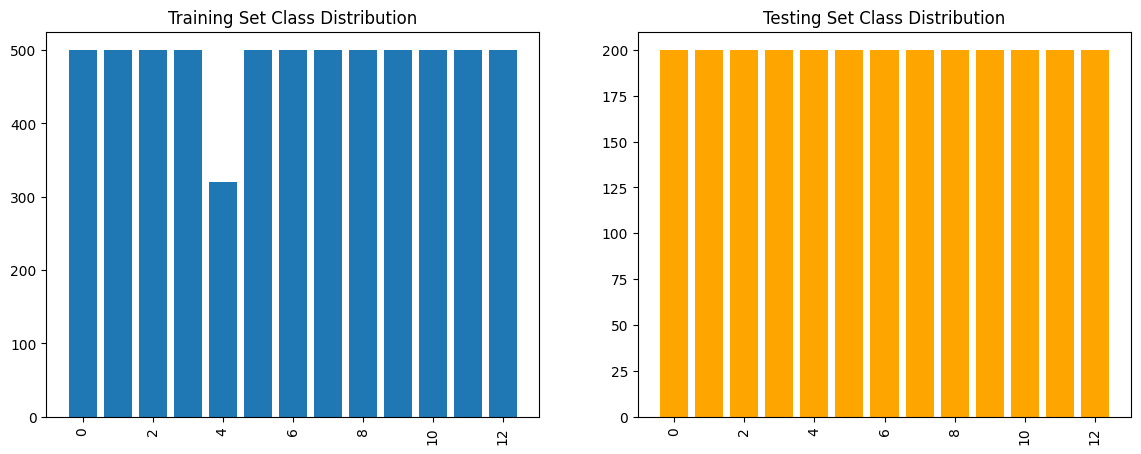

In [ ]:
# Check class distribution
def extract_graph_label(g):
    # The graph label is stored in g.graph_label
    if hasattr(g, 'graph_label') and g.graph_label is not None and len(g.graph_label) > 0:
        return int(g.graph_label.item())
    else:
        # If no graph label is found (e.g., for a graph with no nodes), handle appropriately
        # For this dataset, all graphs should have a label, but we add a check.
        # Returning -1 or raising an error depends on how you want to handle such cases.
        # Since all graphs in this dataset should have labels, raising an error is reasonable.
        raise RuntimeError('Graph label not found in g.graph_label.')

train_labels = [extract_graph_label(g) for g in train_graphs]
test_labels  = [extract_graph_label(g) for g in test_graphs]
unique, counts = np.unique(train_labels, return_counts=True)
print('Train class counts:')
for u,c in zip(unique, counts):
    print(f'  class {u}: {c}')
unique_t, counts_t = np.unique(test_labels, return_counts=True)
print('Test class counts:')
for u,c in zip(unique_t, counts_t):
    print(f'  class {u}: {c}')

# --- Visualization ---
train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.keys(), train_counts.values())
axes[0].set_title("Training Set Class Distribution")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(test_counts.keys(), test_counts.values(), color='orange')
axes[1].set_title("Testing Set Class Distribution")
axes[1].tick_params(axis='x', rotation=90)

plt.show()

The dataset is generally well-balanced across classes. Most classes in the training set have 500 samples, while class 4 has slightly fewer (320 samples), indicating a minor imbalance.  
The test set is perfectly balanced, with 200 samples for each class.  
Overall, the data distribution is nearly uniform, with only a small deviation for class 4.

### 2. DataLoaders

**Define DataLoaders**

In [ ]:
from torch.utils.data import random_split

class ListGraphDataset(Dataset):
    def __init__(self, graphs, labels):
        assert len(graphs) == len(labels)
        self.graphs = graphs
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        return self.graphs[idx], self.labels[idx]

# Create dataset objects
train_dataset = ListGraphDataset(train_graphs, train_labels_int)
test_dataset  = ListGraphDataset(test_graphs, test_labels_int)

# create internal split (85/15)
N = len(train_dataset)
n_val = int(0.15 * N)
n_train = N - n_val
gen = torch.Generator().manual_seed(seed)
train_subset, val_subset = random_split(train_dataset, [n_train, n_val], generator=gen)

# Basic dataloaders (batch size to be tuned later)
# DataLoaders: each batch yields (batched_graphs, labels_tensor)
batch_size = 32
train_loader = GraphDataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader   = GraphDataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader  = GraphDataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_subset), "Val size:", len(val_subset), "Test size:", len(test_dataset))


Train size: 5372 Val size: 948 Test size: 2600


### 3. Model definitions

**Define models (GIN, GAT, DiffPool)**

Three GNN variants with increasing architectural complexity and representational power are defined:

- **GIN (Graph Isomorphism Network)**  
  A strong baseline with MLP-based aggregation due to its high discriminative capacity for graph structures.  
  GIN captures subtle differences in topology, making it particularly suitable for structured biological data such as RNA secondary trees.

- **GAT (Graph Attention Network)**  
  Extends GIN by introducing attention mechanisms, allowing the model to assign different weights to neighboring nodes to learn which neighboring nodes are more informative.  
  This selective aggregation improves performance in heterogeneous or irregular graph structures.

- **DiffPool (Differentiable Pooling Network)**  
  Adds a hierarchical pooling layer that clusters nodes during learning. This is especially useful for capturing multi-level or modular organization in RNA secondary structures.

This sequence — **GIN → GAT → DiffPool** — provides a logical progression from simple neighborhood aggregation, to adaptive attention mechanisms, and finally to hierarchical graph abstraction.  
It allows for a deeper understanding of how structural modeling complexity impacts ncRNA classification performance.


**Update**: We need to modify the GINNet, GATNet, and GCNNet classes to accept an **aggregation parameter** during initialization and use it to select between **sum** or **mean** aggregation in their forward methods. This will involve **updating** the `__init__` and `forward` methods of each of these classes. The DiffPoolNet definition does not need to be changed as its aggregation mechanism (dense_diff_pool) is inherent to its design and not controlled by a simple sum/mean switch.

In [ ]:
#Define GIN and GAT models that operate on DGL batched graphs.
# GINNet
class GINNet(nn.Module):
    """
    GIN-based graph-level classifier using sum-aggregation MLP per node,
    followed by graph readout (mean) and classifier.
    """
    def __init__(self, in_feats, hidden_dim, num_classes, n_layers, dropout, aggregation='mean'):
        super().__init__()
        self.layers = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(n_layers):
            mlp = nn.Sequential(
                nn.Linear(in_feats if i==0 else hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.layers.append(GINConv(mlp, 'sum'))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.dropout = nn.Dropout(dropout)
        self.readout = nn.Linear(hidden_dim, num_classes)
        self.aggregation = aggregation # Store aggregation method

    def forward(self, g, feats):
        h = feats
        for conv, bn in zip(self.layers, self.bns):
            h = conv(g, h)
            h = bn(h)
            h = F.relu(h)
            h = self.dropout(h)
        # graph-level readout (mean or sum)
        g.ndata['h'] = h
        if self.aggregation == 'sum': # Conditional aggregation
            hg = dgl.sum_nodes(g, 'h')
        else:
            hg = dgl.mean_nodes(g, 'h')
        return self.readout(hg)

# GATNet
class GATNet(nn.Module):
    """
    Multi-head GAT for node embeddings, then graph-level readout + classifier.
    """
    def __init__(self, in_feats, hidden_dim, num_classes, num_heads=4, n_layers=2, dropout=0.5, aggregation='mean'):
        super().__init__()
        self.layers = nn.ModuleList()
        self.num_heads = num_heads
        # input layer
        self.layers.append(GATConv(in_feats, hidden_dim // num_heads, num_heads,
                                   feat_drop=dropout, attn_drop=dropout, activation=F.elu))
        # hidden layers
        for _ in range(n_layers-1):
            self.layers.append(GATConv(hidden_dim, hidden_dim // num_heads, num_heads,
                                       feat_drop=dropout, attn_drop=dropout, activation=F.elu))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.aggregation = aggregation # Store aggregation method

    def forward(self, g, feats):
        h = feats
        for layer in self.layers:
            h = layer(g, h)
            if isinstance(h, tuple):
                h = h[0]
            if h.dim() == 3:
                # flatten multi-head output (N, heads, out_dim) -> (N, heads*out_dim)
                h = h.view(h.size(0), -1)
            h = self.dropout(h)
        g.ndata['h'] = h
        if self.aggregation == 'sum': # Conditional aggregation
            hg = dgl.sum_nodes(g, 'h')
        else:
            hg = dgl.mean_nodes(g, 'h')
        return self.fc(hg)

class DiffPoolNet(nn.Module):
    def __init__(self, in_feats, hidden_dim, embed_dim, assign_dim, num_classes, dropout=0.5):
        super().__init__()
        # Minimal two-layer conv + readout
        self.conv1 = GraphConv(in_feats, hidden_dim)
        self.conv2 = GraphConv(hidden_dim, embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)
        self.dropout = nn.Dropout(dropout)
    def forward(self, g, feats):
        h = F.relu(self.conv1(g, feats))
        h = self.dropout(h)
        h = F.relu(self.conv2(g, h))
        g.ndata['h'] = h
        hg = dgl.mean_nodes(g, 'h')
        return self.fc(hg)

### 4. Training and Evaluation Utils

**Evaluate metrics**

Functions to collect logits/labels, compute AUC-ROC (macro), AUC-PR (macro), accuracy and misclassification percentage.


In [ ]:
def evaluate_metrics_collect(model, dataloader, device):
    """
    Evaluate model on dataloader, collect logits and labels.
    Args:
      model: GNN model
      dataloader: GraphDataLoader object
    Returns:
      metrics (dict) :
        - Loss (BCEWithLogits)
        - Accuracy (multi-label)
        - AUC-ROC (macro)
        - AUC-PR (macro)
        - Misclassification Percentage,
      logits (Tensor: N x C),
      labels (Tensor: N)
    """
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    all_logits = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batched_graphs, labels in dataloader:
            batched_graphs = batched_graphs.to(device)
            feats = batched_graphs.ndata['feat'].float().to(device)
            labels = labels.to(device)

            logits = model(batched_graphs, feats)   # (B, C)
            loss = loss_fn(logits, labels)

            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

    logits_all = torch.cat(all_logits, dim=0)
    labels_all = torch.cat(all_labels, dim=0)
    avg_loss = total_loss / total_samples

    probs = torch.softmax(logits_all, dim=1).numpy()
    labels_np = labels_all.numpy()
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(labels_np, preds)
    misclass_pct = (1.0 - acc) * 100.0

    # Macro AUC/PR
    try:
        y_true_bin = label_binarize(labels_np, classes=np.arange(probs.shape[1]))
        auc_roc = roc_auc_score(y_true_bin, probs, average='macro')
        auc_pr = average_precision_score(y_true_bin, probs, average='macro')
    except Exception:
        auc_roc, auc_pr = float('nan'), float('nan')

    metrics = {
        'loss': avg_loss,
        'accuracy': float(acc),
        'auc_roc': float(auc_roc),
        'auc_pr': float(auc_pr),
        'misclassification_pct': float(misclass_pct)
    }
    return metrics, logits_all, labels_all

### Train models

We will integrate a **learning rate scheduler** (e.g., ReduceLROnPlateau or CosineAnnealingLR) to dynamically adjust the learning rate during training, allowing **for better convergence**. Also, implement **gradient clipping** to **prevent exploding gradients**, which can destabilize training, especially in deeper GNNs. These will be added to the `train_model` function.


In [ ]:
from torch.optim import lr_scheduler

def train_model(model, train_loader, val_loader, loss_fn, optimizer, device, num_epochs=30, scheduler=None, grad_clip_norm=None, class_weights=None):
    """
    Train the model and record losses for training and validation sets.
    Returns a history dictionary containing losses and accuracies.
    Args:
        model: DGL GNN model
        train_loader, val_loader: GraphDataLoader objects
        loss_fn: CrossEntropyLoss()
        optimizer: torch optimizer
        device: cuda or cpu
        num_epochs: training epochs
        scheduler: learning rate scheduler (optional)
        grad_clip_norm: gradient clipping norm value (optional)
        class_weights: weights for CrossEntropyLoss (optional)
    Returns:
        model: trained model
        history: dict of losses and accuracies
    """

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    model.to(device)

    # If class_weights are provided, use a weighted CrossEntropyLoss
    # Otherwise, use the provided loss_fn
    current_loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device)) if class_weights is not None else loss_fn

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batched_graphs, labels in train_loader:
            batched_graphs = batched_graphs.to(device)
            feats = batched_graphs.ndata['feat'].float().to(device)
            labels = labels.to(device)  # shape: (batch_size,)

            logits = model(batched_graphs, feats)  # expected shape: (B, C)
            loss = current_loss_fn(logits, labels) # Use current_loss_fn

            optimizer.zero_grad()
            loss.backward()

            # Apply gradient clipping
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

            optimizer.step()

            # accumulate
            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = total_loss / total
        train_acc = correct / total

        # Evaluate on validation
        val_metrics, _, _ = evaluate_metrics_collect(model, val_loader, device)
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_metrics["accuracy"])

        # Step the scheduler
        if scheduler is not None:
            if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        print(f"Epoch {epoch:02d}: TrainLoss={avg_train_loss:.4f}, ValLoss={val_metrics['loss']:.4f}, "
              f"TrainAcc={train_acc:.4f}, ValAcc={val_metrics['accuracy']:.4f}")

    return model, history

In [ ]:
def plot_loss_curves(history, model_name="Model"):
    """
    Plot training and validation loss/accuracy curves.
    Helps visualize possible overfitting.
    """
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    # Plot Loss
    ax[0].plot(epochs, history["train_loss"], label="Train Loss")
    ax[0].plot(epochs, history["val_loss"], label="Val Loss", linestyle="--")
    ax[0].set_title(f"{model_name} - Loss Curves")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Plot Accuracy
    ax[1].plot(epochs, history["train_acc"], label="Train Acc")
    ax[1].plot(epochs, history["val_acc"], label="Val Acc", linestyle="--")
    ax[1].set_title(f"{model_name} - Accuracy Curves")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def _build_model_from_cls(model_cls, arch_config, in_feats, num_classes, device):
    """Helper to instantiate model depending on class name."""
    name = model_cls.__name__
    if name == 'GINNet':
        return model_cls(in_feats=in_feats,
                         hidden_dim=arch_config['hidden_dim'],
                         num_classes=num_classes,
                         n_layers=arch_config['num_layers'],
                         dropout=arch_config.get('dropout', 0.1),
                         aggregation=arch_config.get('aggregation', 'mean')).to(device)
    elif name == 'GATNet':
        return model_cls(in_feats=in_feats,
                         hidden_dim=arch_config['hidden_dim'],
                         num_classes=num_classes,
                         n_layers=arch_config['num_layers'],
                         num_heads=arch_config.get('num_heads', 4),
                         dropout=arch_config.get('dropout', 0.1),
                         aggregation=arch_config.get('aggregation', 'mean')).to(device)
    elif name == 'DiffPoolNet':
        return model_cls(in_feats=in_feats,
                         hidden_dim=arch_config['hidden_dim'],
                         embed_dim=arch_config.get('embed_dim', arch_config['hidden_dim']),
                         assign_dim=arch_config.get('assign_dim', max(4, arch_config['hidden_dim']//4)),
                         num_classes=num_classes,
                         dropout=arch_config.get('dropout', 0.5)).to(device)
    else:
        # fallback: try to call with generic args (may raise error if signature differs)
        return model_cls(in_feats=in_feats,
                         hidden_dim=arch_config.get('hidden_dim', 64),
                         num_classes=num_classes).to(device)

**BANANAS Architecture Search**

BANANAS is a neural architecture search (NAS) algorithm which uses Bayesian optimization with a meta neural network to predict the validation accuracy of neural architectures (White et al., 2020).   
This is a compact, runnable BANANAS-inspired implementation:
- encode architectures as numeric vectors (simple encoding)
- use a small surrogate ensemble (simple MLPs): it predicts validation accuracy and guides exploration via Expected Improvement (EI).
- fit surrogate on collected (arch -> val_acc)
- propose candidates, compute EI, evaluate on short training (short_epochs)
- iterate and return best architecture

<p align="center">
<img src="https://github.com/naszilla/naszilla/raw/master/img/bananas.png" width="650" height="400"/>
</p>

In [ ]:
from scipy.stats import norm
from copy import deepcopy

# Small surrogate MLP (bagging ensemble) used to emulate BANANAS surrogate
class SmallMLP(nn.Module):
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(), nn.Linear(hidden,1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

class SurrogateEnsemble:
    def __init__(self, in_dim, n_models=3, lr=1e-3, device='cpu'):
        self.device = device
        self.models = [SmallMLP(in_dim).to(device) for _ in range(n_models)]
        self.opts = [torch.optim.Adam(m.parameters(), lr=lr) for m in self.models]
        self.crit = nn.MSELoss()

    def fit(self, X, y, epochs=50):
        # X: list/array (n_samples, dim)
        X = torch.tensor(np.array(X), dtype=torch.float32).to(self.device)
        y = torch.tensor(np.array(y), dtype=torch.float32).to(self.device)
        n = len(self.models)  # or n = X_t.shape[0]
        for i, (m, opt) in enumerate(zip(self.models, self.opts)):
            for e in range(epochs):
                m.train()
                pred = m(X)
                loss = self.crit(pred, y)
                opt.zero_grad()
                loss.backward()
                opt.step()

    def predict(self, X):
        X = torch.tensor(np.array(X), dtype=torch.float32).to(self.device)
        preds = []
        with torch.no_grad():
            for m in self.models:
                m.eval()
                preds.append(m(X).cpu().numpy())
        preds = np.stack(preds, axis=0)
        return preds.mean(axis=0), preds.std(axis=0) + 1e-3

def expected_improvement(mu, sigma, best, xi=0.01):
    # Standard EI formulation for maximization
    with np.errstate(divide='warn'):
        imp = mu - best - xi
        Z = imp / (sigma + 1e-9)
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma==0.0] = 0.0
    return ei

# Example function to run BANANAS for one model (GIN/GAT/DiffPool)
def bananas_search(
    model_name,
    model_class,
    arch_space,
    train_dataset,
    device=device,
    config=None,
    seed=42
):
    """
    model_name: 'GIN'|'GAT'|'DiffPool'|'GCN'
    model_class: class object reference (e.g., GINNet)
    arch_space: dict: param_name -> list_of_choices (categorical or numeric)
    num_init: number of initial random architectures to evaluate
    num_iter: number of BANANAS iterations
    surrogate_epochs: epochs to train the surrogate ensemble
    returns: best_arch (dict), best_val_acc
    """
    # Extract configuration or use defaults
    num_init = config.get('num_init', 5) if config else 5
    num_iters = config.get('num_iter', 15) if config else 15
    candidates_per_iter = config.get('candidates_per_iter', 20) if config else 20
    short_epochs = config.get('short_epochs', 15) if config else 15
    short_lr = config.get('short_lr', 1e-3) if config else 1e-3
    short_wd = config.get('short_wd', 5e-4) if config else 5e-4
    batch_size = config.get('batch_size', 32) if config else 32
    surrogate_n_models = config.get('surrogate_n_models', 3) if config else 3
    surrogate_epochs = config.get('surrogate_epochs', 50) if config else 50
    surrogate_lr = config.get('surrogate_lr', 1e-3) if config else 1e-3
    xi = config.get('ei_xi', 0.01) if config else 0.01

    print(f"\n===== BANANAS SEARCH for {model_name} =====")

    # Step 1. Define search space as list of keys
    search_keys = list(arch_space.keys())

    # Step 2. Helper to sample a random architecture
    def sample_arch():
        arch = {}
        for k, v in arch_space.items():
            if isinstance(v[0], float):
                # Sample continuous variables
                arch[k] = float(np.random.uniform(min(v), max(v)))
            elif k == 'aggregation': # Handle categorical aggregation
                arch[k] = random.choice(v)
            else:
                # Sample discrete variables (integers)
                arch[k] = int(np.random.choice(v))
        return arch

    # ---------------- Mutation ----------------
    def mutate_arch(arch):
        arch_new = deepcopy(arch)
        k = np.random.choice(list(arch_space.keys()))
        v = arch_space[k]
        if isinstance(v[0], float):
            arch_new[k] = float(np.random.uniform(min(v), max(v)))
        elif k == 'aggregation': # Handle categorical aggregation
            arch_new[k] = random.choice(v)
        else:
            arch_new[k] = int(np.random.choice(v))
        return arch_new

    # Step 3. Encode architecture as numeric vector
    def encode_arch(arch):
        encoded = []
        # numeric/categorical hyperparameters
        for k in search_keys:
            if k == 'aggregation':
                # Map 'sum' to 0, 'mean' to 1 for numerical representation
                encoded.append(0.0 if arch[k] == 'sum' else 1.0)
            else:
                encoded.append(arch[k])

        num_paths = 10 # This is a placeholder for `naszilla.nas_alghorithms.bananas`
        path_vec = np.random.randint(0, 2, size=num_paths)
        encoded.extend(path_vec)
        return np.array(encoded, dtype=np.float32)

    # Step 4. Evaluate a single architecture (short train)
    def evaluate_arch(arch, arch_id=None):

        # DataLoaders for short training
        train_loader_local = GraphDataLoader(train_subset, batch_size=batch_size, shuffle=True) # Use _new datasets
        val_loader_local   = GraphDataLoader(val_subset, batch_size=batch_size, shuffle=False)   # Use _new datasets

        print(f"\n[TRAINING] Model={model_name}, ArchID={arch_id if arch_id else 'init'}")
        print(f" Config: {arch}")

        # Create model instance based on architecture
        # Use in_feats_new for updated feature dimension
        model = _build_model_from_cls(model_class, arch, in_feats, num_classes, device)

        optimizer = torch.optim.Adam(model.parameters(), lr=short_lr, weight_decay=short_wd)
        loss_fn = nn.CrossEntropyLoss()

        # short training with validation
        model, history = train_model(
            model,
            train_loader_local,
            val_loader_local,
            loss_fn,
            optimizer,
            device,
            num_epochs=short_epochs
        )

        # Find best validation accuracy during short training
        val_acc = max(history['val_acc'])
        plot_loss_curves(history)

        return val_acc

    # Step 5. Initialize with random architectures
    archs = [sample_arch() for _ in range(num_init)]
    X_train = [encode_arch(a) for a in archs]
    y_train = [evaluate_arch(a, arch_id=f"init{i+1}") for i, a in enumerate(archs)]

    # Step 6. Surrogate ensemble (MLPs)
    input_dim = len(X_train[0])
    surrogate = SurrogateEnsemble(in_dim=input_dim, n_models=surrogate_n_models, lr=surrogate_lr, device=device)

    # Step 7. Iterative search loop
    for it in range(num_iters):
        surrogate.fit(X_train, y_train, epochs=surrogate_epochs)

        # Generate candidates by mutation
        candidates = [mutate_arch(random.choice(archs)) for _ in range(candidates_per_iter)]
        X_cand = np.array([encode_arch(c) for c in candidates])

        mu, sigma = surrogate.predict(X_cand)
        best_y = np.max(y_train)
        ei = expected_improvement(mu, sigma, best_y, xi=xi)
        next_idx = np.argmax(ei)

        next_arch = candidates[next_idx]
        next_val_acc = evaluate_arch(next_arch, arch_id=f"iter{it+1}")

        X_train.append(encode_arch(next_arch))
        y_train.append(next_val_acc)
        archs.append(next_arch)

        print(f"[{model_name}] Iter {it+1}/{num_iters} | New Arch {next_arch} -> ValAcc={next_val_acc:.4f}")

    # Step 8. Select best architecture
    best_idx = np.argmax(y_train)
    # Note: best_arch might come from initial random samples or search iterations
    # Retrieve the best architecture dictionary directly from the list `archs`
    best_arch = archs[best_idx]
    best_val_acc = y_train[best_idx]

    print(f"\n=== Best {model_name} Architecture ===")
    print(best_arch, f"Validation Accuracy: {best_val_acc:.4f}")

    return best_arch, best_val_acc



**Architecture search spaces**  
Define which architecture parameters BANANAS will search for each model.
These are the architecture-level parameters (not training hyperparameters).  
Aggregation parameter is added to the search spaces.

Running BANANAS architecture search for GIN, GAT, and GCN models...

===== BANANAS SEARCH for GIN =====

[TRAINING] Model=GIN, ArchID=init1
 Config: {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.49070786091683194, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.3328, ValLoss=2.1308, TrainAcc=0.1808, ValAcc=0.2690
Epoch 02: TrainLoss=2.1443, ValLoss=1.9820, TrainAcc=0.2541, ValAcc=0.3101
Epoch 03: TrainLoss=2.0800, ValLoss=1.9481, TrainAcc=0.2612, ValAcc=0.3386
Epoch 04: TrainLoss=2.0608, ValLoss=1.9301, TrainAcc=0.2846, ValAcc=0.3544
Epoch 05: TrainLoss=2.0154, ValLoss=1.9036, TrainAcc=0.3103, ValAcc=0.3460
Epoch 06: TrainLoss=1.9998, ValLoss=1.9034, TrainAcc=0.3092, ValAcc=0.3439
Epoch 07: TrainLoss=1.9908, ValLoss=1.8600, TrainAcc=0.3152, ValAcc=0.3713
Epoch 08: TrainLoss=1.9709, ValLoss=1.8856, TrainAcc=0.3299, ValAcc=0.3565
Epoch 09: TrainLoss=1.9446, ValLoss=1.8665, TrainAcc=0.3360, ValAcc=0.3650
Epoch 10: TrainLoss=1.9560, ValLoss=1.8404, TrainAcc=0.3304, ValAcc=0.3713
Epoch 11: 

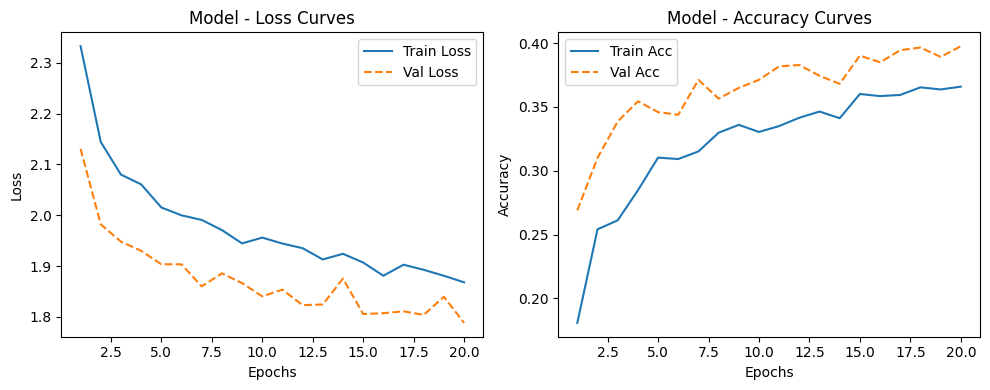


[TRAINING] Model=GIN, ArchID=init2
 Config: {'hidden_dim': 32, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'sum'}
Epoch 01: TrainLoss=2.8148, ValLoss=2.2726, TrainAcc=0.1562, ValAcc=0.2057
Epoch 02: TrainLoss=2.3715, ValLoss=2.0622, TrainAcc=0.2040, ValAcc=0.2975
Epoch 03: TrainLoss=2.2399, ValLoss=1.9969, TrainAcc=0.2386, ValAcc=0.3344
Epoch 04: TrainLoss=2.1626, ValLoss=1.9827, TrainAcc=0.2690, ValAcc=0.3333
Epoch 05: TrainLoss=2.1116, ValLoss=1.9115, TrainAcc=0.2796, ValAcc=0.3523
Epoch 06: TrainLoss=2.0702, ValLoss=1.8980, TrainAcc=0.2967, ValAcc=0.3681
Epoch 07: TrainLoss=2.0203, ValLoss=1.8716, TrainAcc=0.3062, ValAcc=0.3597
Epoch 08: TrainLoss=2.0038, ValLoss=1.8850, TrainAcc=0.3120, ValAcc=0.3534
Epoch 09: TrainLoss=1.9809, ValLoss=1.8710, TrainAcc=0.3250, ValAcc=0.3703
Epoch 10: TrainLoss=1.9790, ValLoss=1.8510, TrainAcc=0.3215, ValAcc=0.3639
Epoch 11: TrainLoss=1.9513, ValLoss=1.8316, TrainAcc=0.3312, ValAcc=0.3724
Epoch 12: TrainLoss=1.9197, ValLoss=1.82

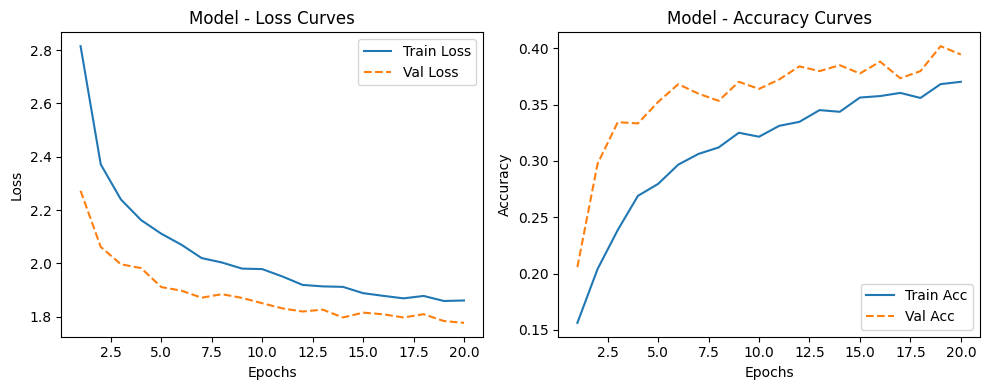


[TRAINING] Model=GIN, ArchID=init3
 Config: {'hidden_dim': 64, 'num_layers': 4, 'dropout': 0.13060008563695646, 'aggregation': 'sum'}
Epoch 01: TrainLoss=2.5179, ValLoss=2.0989, TrainAcc=0.2280, ValAcc=0.2911
Epoch 02: TrainLoss=2.1353, ValLoss=1.9679, TrainAcc=0.2889, ValAcc=0.3270
Epoch 03: TrainLoss=2.0529, ValLoss=2.0886, TrainAcc=0.3073, ValAcc=0.2943
Epoch 04: TrainLoss=2.0281, ValLoss=1.8923, TrainAcc=0.3222, ValAcc=0.3787
Epoch 05: TrainLoss=1.9936, ValLoss=1.8669, TrainAcc=0.3364, ValAcc=0.3797
Epoch 06: TrainLoss=1.9587, ValLoss=1.8733, TrainAcc=0.3349, ValAcc=0.3639
Epoch 07: TrainLoss=1.9027, ValLoss=1.8575, TrainAcc=0.3658, ValAcc=0.3660
Epoch 08: TrainLoss=1.8830, ValLoss=1.8101, TrainAcc=0.3600, ValAcc=0.3966
Epoch 09: TrainLoss=1.8638, ValLoss=1.8769, TrainAcc=0.3727, ValAcc=0.3776
Epoch 10: TrainLoss=1.8510, ValLoss=1.8280, TrainAcc=0.3757, ValAcc=0.4093
Epoch 11: TrainLoss=1.8407, ValLoss=1.8111, TrainAcc=0.3749, ValAcc=0.3766
Epoch 12: TrainLoss=1.8132, ValLoss=1.83

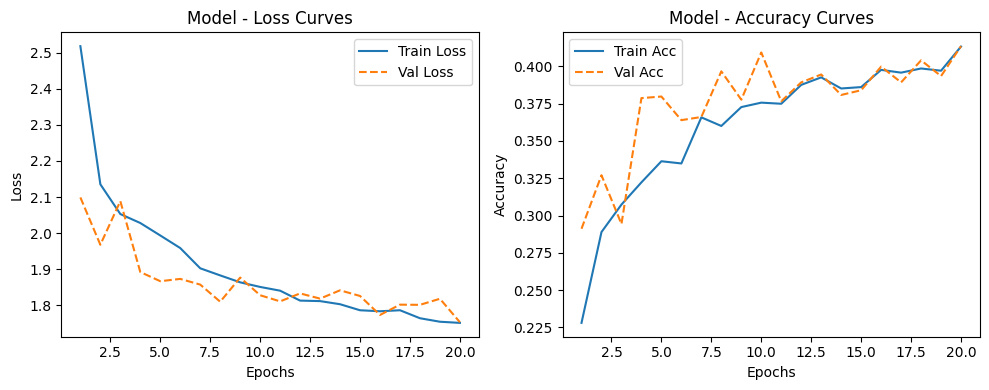


[TRAINING] Model=GIN, ArchID=iter1
 Config: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'sum'}
Epoch 01: TrainLoss=2.6229, ValLoss=2.2378, TrainAcc=0.2159, ValAcc=0.2996
Epoch 02: TrainLoss=2.2885, ValLoss=2.0348, TrainAcc=0.2794, ValAcc=0.3734
Epoch 03: TrainLoss=2.1986, ValLoss=1.9507, TrainAcc=0.2872, ValAcc=0.3386
Epoch 04: TrainLoss=2.1568, ValLoss=1.9149, TrainAcc=0.2975, ValAcc=0.3586
Epoch 05: TrainLoss=2.0799, ValLoss=1.9193, TrainAcc=0.3198, ValAcc=0.3586
Epoch 06: TrainLoss=2.0279, ValLoss=1.9600, TrainAcc=0.3313, ValAcc=0.3618
Epoch 07: TrainLoss=1.9913, ValLoss=2.0115, TrainAcc=0.3310, ValAcc=0.3513
Epoch 08: TrainLoss=1.9464, ValLoss=1.8710, TrainAcc=0.3515, ValAcc=0.3882
Epoch 09: TrainLoss=1.8927, ValLoss=1.8112, TrainAcc=0.3712, ValAcc=0.4030
Epoch 10: TrainLoss=1.9095, ValLoss=1.8380, TrainAcc=0.3563, ValAcc=0.4019
Epoch 11: TrainLoss=1.8684, ValLoss=1.9125, TrainAcc=0.3732, ValAcc=0.3776
Epoch 12: TrainLoss=1.8518, ValLoss=1.7

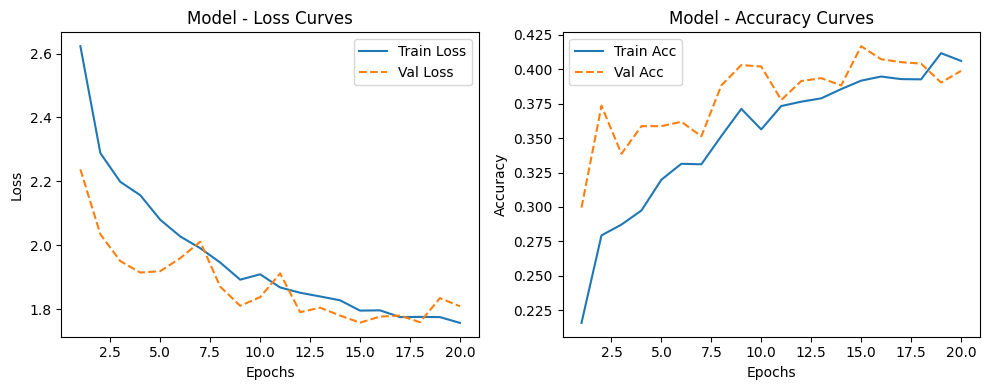

[GIN] Iter 1/6 | New Arch {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'sum'} -> ValAcc=0.4167

[TRAINING] Model=GIN, ArchID=iter2
 Config: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.1184, ValLoss=1.9746, TrainAcc=0.2781, ValAcc=0.3291
Epoch 02: TrainLoss=1.9680, ValLoss=1.8585, TrainAcc=0.3237, ValAcc=0.3861
Epoch 03: TrainLoss=1.9259, ValLoss=1.8628, TrainAcc=0.3444, ValAcc=0.3629
Epoch 04: TrainLoss=1.8895, ValLoss=1.7975, TrainAcc=0.3505, ValAcc=0.3998
Epoch 05: TrainLoss=1.8615, ValLoss=1.7966, TrainAcc=0.3637, ValAcc=0.3956
Epoch 06: TrainLoss=1.8364, ValLoss=1.7790, TrainAcc=0.3743, ValAcc=0.4051
Epoch 07: TrainLoss=1.8070, ValLoss=1.7682, TrainAcc=0.3878, ValAcc=0.4146
Epoch 08: TrainLoss=1.7989, ValLoss=1.7650, TrainAcc=0.3891, ValAcc=0.4040
Epoch 09: TrainLoss=1.7879, ValLoss=1.7962, TrainAcc=0.3894, ValAcc=0.3945
Epoch 10: TrainLoss=1.7870, ValLoss=1.7828, TrainAcc=0

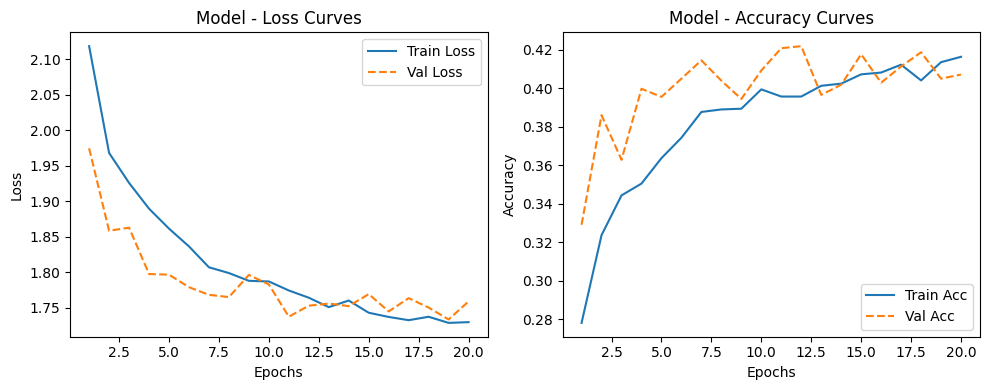

[GIN] Iter 2/6 | New Arch {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'} -> ValAcc=0.4219

[TRAINING] Model=GIN, ArchID=iter3
 Config: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.2972741913058286, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.0720, ValLoss=1.9207, TrainAcc=0.2882, ValAcc=0.3544
Epoch 02: TrainLoss=1.9535, ValLoss=1.8669, TrainAcc=0.3321, ValAcc=0.3703
Epoch 03: TrainLoss=1.8963, ValLoss=1.8346, TrainAcc=0.3559, ValAcc=0.3755
Epoch 04: TrainLoss=1.8621, ValLoss=1.8267, TrainAcc=0.3678, ValAcc=0.3903
Epoch 05: TrainLoss=1.8435, ValLoss=1.7944, TrainAcc=0.3647, ValAcc=0.3935
Epoch 06: TrainLoss=1.8165, ValLoss=1.7983, TrainAcc=0.3742, ValAcc=0.3914
Epoch 07: TrainLoss=1.8076, ValLoss=1.7739, TrainAcc=0.3831, ValAcc=0.4093
Epoch 08: TrainLoss=1.7958, ValLoss=1.7555, TrainAcc=0.3933, ValAcc=0.4124
Epoch 09: TrainLoss=1.7620, ValLoss=1.7589, TrainAcc=0.4004, ValAcc=0.4030
Epoch 10: TrainLoss=1.7699, ValLoss=1.7911, TrainAcc=0

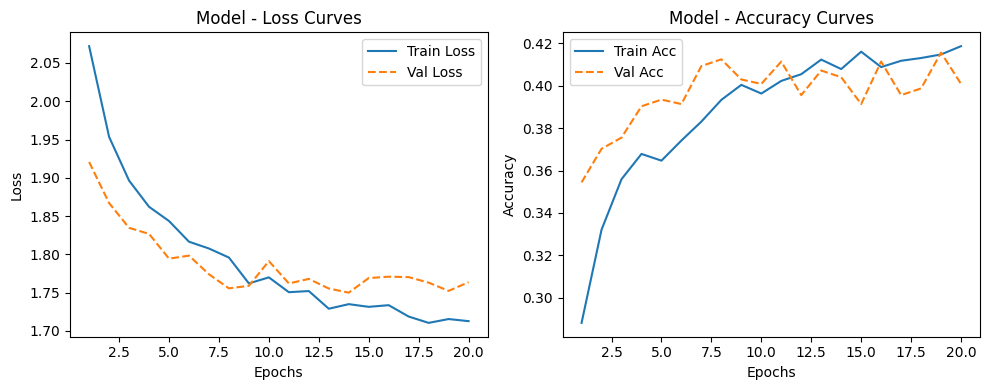

[GIN] Iter 3/6 | New Arch {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.2972741913058286, 'aggregation': 'mean'} -> ValAcc=0.4156

[TRAINING] Model=GIN, ArchID=iter4
 Config: {'hidden_dim': 128, 'num_layers': 4, 'dropout': 0.13060008563695646, 'aggregation': 'sum'}
Epoch 01: TrainLoss=2.5070, ValLoss=2.0159, TrainAcc=0.2260, ValAcc=0.3354
Epoch 02: TrainLoss=2.1989, ValLoss=2.1175, TrainAcc=0.2831, ValAcc=0.3049
Epoch 03: TrainLoss=2.0985, ValLoss=2.1465, TrainAcc=0.3044, ValAcc=0.3397
Epoch 04: TrainLoss=2.0650, ValLoss=1.9153, TrainAcc=0.3241, ValAcc=0.3460
Epoch 05: TrainLoss=2.0292, ValLoss=1.9708, TrainAcc=0.3358, ValAcc=0.3386
Epoch 06: TrainLoss=2.0030, ValLoss=1.9464, TrainAcc=0.3341, ValAcc=0.3745
Epoch 07: TrainLoss=1.9787, ValLoss=1.9971, TrainAcc=0.3518, ValAcc=0.3766
Epoch 08: TrainLoss=1.9616, ValLoss=1.9734, TrainAcc=0.3576, ValAcc=0.3882
Epoch 09: TrainLoss=1.9293, ValLoss=2.2584, TrainAcc=0.3634, ValAcc=0.3639
Epoch 10: TrainLoss=1.9084, ValLoss=1.9146, TrainAcc=0.

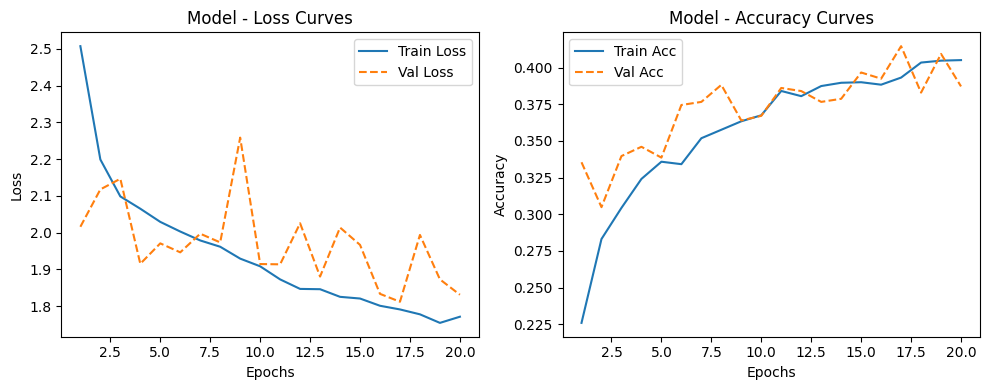

[GIN] Iter 4/6 | New Arch {'hidden_dim': 128, 'num_layers': 4, 'dropout': 0.13060008563695646, 'aggregation': 'sum'} -> ValAcc=0.4146

[TRAINING] Model=GIN, ArchID=iter5
 Config: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.2972741913058286, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.1748, ValLoss=1.9939, TrainAcc=0.2535, ValAcc=0.3027
Epoch 02: TrainLoss=2.0080, ValLoss=1.9244, TrainAcc=0.3021, ValAcc=0.3376
Epoch 03: TrainLoss=1.9656, ValLoss=1.8859, TrainAcc=0.3220, ValAcc=0.3618
Epoch 04: TrainLoss=1.9318, ValLoss=1.9058, TrainAcc=0.3354, ValAcc=0.3323
Epoch 05: TrainLoss=1.9004, ValLoss=1.8406, TrainAcc=0.3487, ValAcc=0.3597
Epoch 06: TrainLoss=1.8942, ValLoss=1.8378, TrainAcc=0.3578, ValAcc=0.3671
Epoch 07: TrainLoss=1.8894, ValLoss=1.8213, TrainAcc=0.3565, ValAcc=0.3903
Epoch 08: TrainLoss=1.8713, ValLoss=1.8272, TrainAcc=0.3550, ValAcc=0.3840
Epoch 09: TrainLoss=1.8638, ValLoss=1.8224, TrainAcc=0.3628, ValAcc=0.3703
Epoch 10: TrainLoss=1.8637, ValLoss=1.8000, TrainAcc=0.

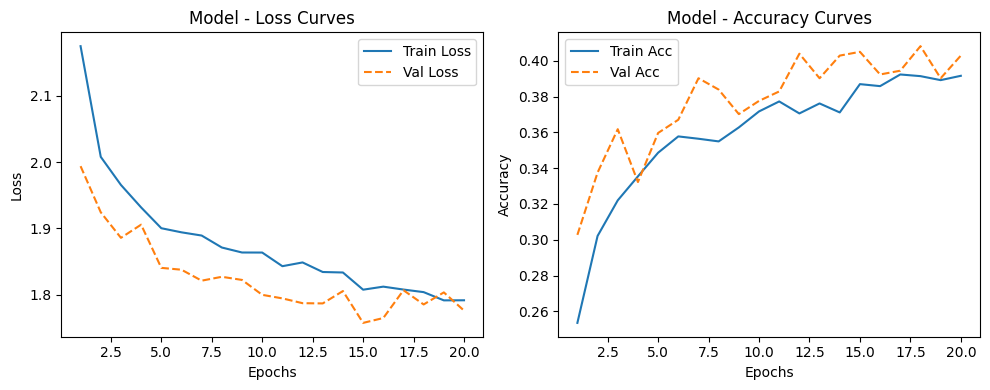

[GIN] Iter 5/6 | New Arch {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.2972741913058286, 'aggregation': 'mean'} -> ValAcc=0.4082

[TRAINING] Model=GIN, ArchID=iter6
 Config: {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.2972741913058286, 'aggregation': 'mean'}
Epoch 01: TrainLoss=2.1496, ValLoss=1.8971, TrainAcc=0.2640, ValAcc=0.3523
Epoch 02: TrainLoss=2.0081, ValLoss=1.8870, TrainAcc=0.3064, ValAcc=0.3671
Epoch 03: TrainLoss=1.9532, ValLoss=1.8885, TrainAcc=0.3345, ValAcc=0.3703
Epoch 04: TrainLoss=1.9350, ValLoss=1.8361, TrainAcc=0.3343, ValAcc=0.3513
Epoch 05: TrainLoss=1.9132, ValLoss=1.8372, TrainAcc=0.3459, ValAcc=0.3871
Epoch 06: TrainLoss=1.8957, ValLoss=1.8714, TrainAcc=0.3555, ValAcc=0.3608
Epoch 07: TrainLoss=1.8847, ValLoss=1.8085, TrainAcc=0.3606, ValAcc=0.3692
Epoch 08: TrainLoss=1.8777, ValLoss=1.8279, TrainAcc=0.3598, ValAcc=0.3903
Epoch 09: TrainLoss=1.8446, ValLoss=1.8477, TrainAcc=0.3686, ValAcc=0.3713
Epoch 10: TrainLoss=1.8382, ValLoss=1.8056, TrainAcc=0.

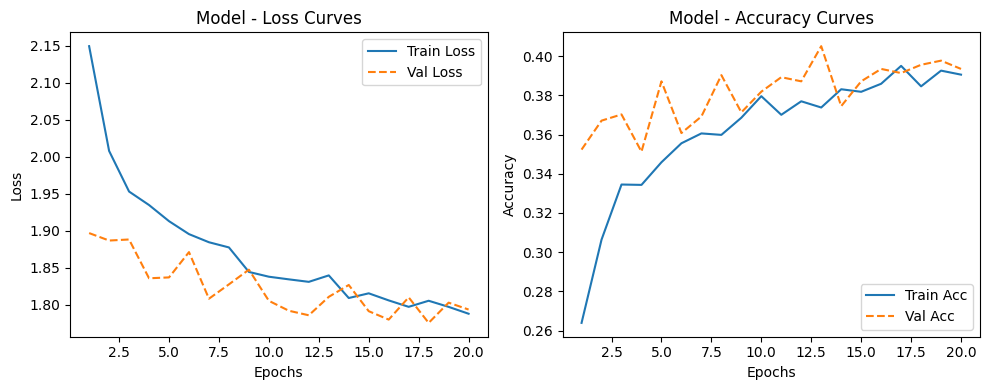

[GIN] Iter 6/6 | New Arch {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.2972741913058286, 'aggregation': 'mean'} -> ValAcc=0.4051

=== Best GIN Architecture ===
{'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'} Validation Accuracy: 0.4219

===== BANANAS SEARCH for GAT =====

[TRAINING] Model=GAT, ArchID=init1
 Config: {'hidden_dim': 32, 'num_layers': 3, 'dropout': 0.46307287363529287, 'num_heads': 4, 'aggregation': 'sum'}
Epoch 01: TrainLoss=15.7266, ValLoss=2.9790, TrainAcc=0.0851, ValAcc=0.0622
Epoch 02: TrainLoss=5.7973, ValLoss=2.6800, TrainAcc=0.0920, ValAcc=0.0717
Epoch 03: TrainLoss=3.3597, ValLoss=2.6062, TrainAcc=0.1020, ValAcc=0.0738
Epoch 04: TrainLoss=2.6942, ValLoss=2.6058, TrainAcc=0.1182, ValAcc=0.0665
Epoch 05: TrainLoss=2.5185, ValLoss=2.6094, TrainAcc=0.1230, ValAcc=0.0791
Epoch 06: TrainLoss=2.4924, ValLoss=2.5527, TrainAcc=0.1294, ValAcc=0.0665
Epoch 07: TrainLoss=2.4697, ValLoss=2.5131, TrainAcc=0.1283, ValAcc=0.0728
Ep

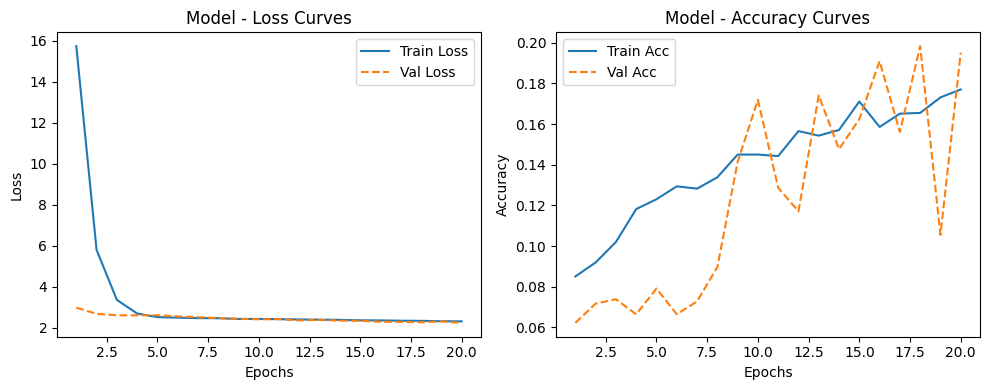


[TRAINING] Model=GAT, ArchID=init2
 Config: {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.17756660765789534, 'num_heads': 4, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.7032, ValLoss=2.2935, TrainAcc=0.1370, ValAcc=0.1793
Epoch 02: TrainLoss=2.5197, ValLoss=2.1650, TrainAcc=0.1644, ValAcc=0.2658
Epoch 03: TrainLoss=2.3655, ValLoss=2.2285, TrainAcc=0.1873, ValAcc=0.2363
Epoch 04: TrainLoss=2.2975, ValLoss=2.1177, TrainAcc=0.2076, ValAcc=0.2563
Epoch 05: TrainLoss=2.2417, ValLoss=2.0969, TrainAcc=0.2271, ValAcc=0.2996
Epoch 06: TrainLoss=2.2362, ValLoss=2.0527, TrainAcc=0.2215, ValAcc=0.2890
Epoch 07: TrainLoss=2.1988, ValLoss=2.0251, TrainAcc=0.2465, ValAcc=0.3112
Epoch 08: TrainLoss=2.1804, ValLoss=2.0890, TrainAcc=0.2504, ValAcc=0.3186
Epoch 09: TrainLoss=2.1612, ValLoss=2.0225, TrainAcc=0.2586, ValAcc=0.3228
Epoch 10: TrainLoss=2.1526, ValLoss=2.0534, TrainAcc=0.2610, ValAcc=0.3091
Epoch 11: TrainLoss=2.1545, ValLoss=2.0107, TrainAcc=0.2561, ValAcc=0.3376
Epoch 12: TrainLoss=2.10

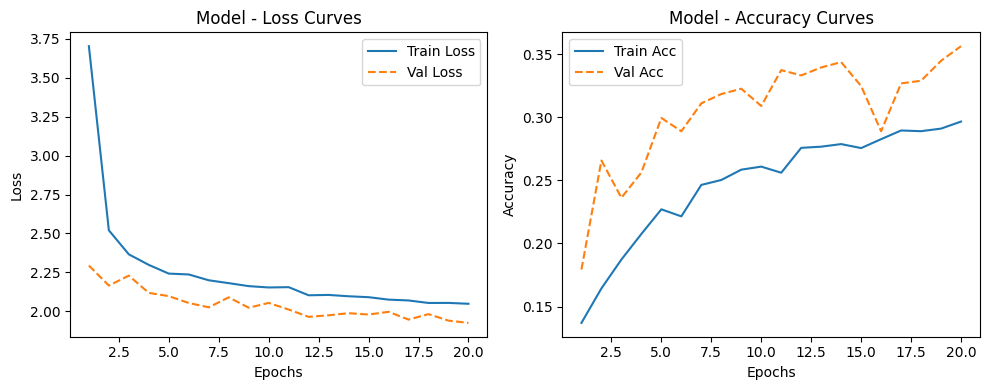


[TRAINING] Model=GAT, ArchID=init3
 Config: {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.2138032437210149, 'num_heads': 2, 'aggregation': 'sum'}
Epoch 01: TrainLoss=4.1051, ValLoss=2.2941, TrainAcc=0.1098, ValAcc=0.1941
Epoch 02: TrainLoss=2.6515, ValLoss=2.2265, TrainAcc=0.1398, ValAcc=0.2257
Epoch 03: TrainLoss=2.4461, ValLoss=2.2090, TrainAcc=0.1586, ValAcc=0.2310
Epoch 04: TrainLoss=2.3496, ValLoss=2.1674, TrainAcc=0.1854, ValAcc=0.2300
Epoch 05: TrainLoss=2.3153, ValLoss=2.1328, TrainAcc=0.1910, ValAcc=0.2679
Epoch 06: TrainLoss=2.2725, ValLoss=2.1321, TrainAcc=0.2042, ValAcc=0.2806
Epoch 07: TrainLoss=2.2536, ValLoss=2.1295, TrainAcc=0.2068, ValAcc=0.2489
Epoch 08: TrainLoss=2.2336, ValLoss=2.0616, TrainAcc=0.2239, ValAcc=0.2658
Epoch 09: TrainLoss=2.2264, ValLoss=2.0582, TrainAcc=0.2174, ValAcc=0.3038
Epoch 10: TrainLoss=2.2012, ValLoss=2.0282, TrainAcc=0.2295, ValAcc=0.3344
Epoch 11: TrainLoss=2.1914, ValLoss=2.0150, TrainAcc=0.2345, ValAcc=0.3259
Epoch 12: TrainLoss=2.170

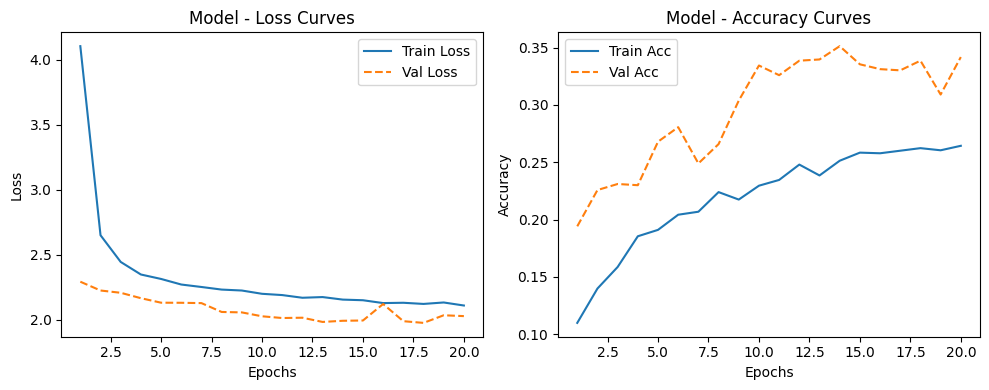


[TRAINING] Model=GAT, ArchID=iter1
 Config: {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.4092, ValLoss=2.2392, TrainAcc=0.1361, ValAcc=0.2257
Epoch 02: TrainLoss=2.4953, ValLoss=2.1134, TrainAcc=0.1688, ValAcc=0.2627
Epoch 03: TrainLoss=2.3333, ValLoss=2.1131, TrainAcc=0.1962, ValAcc=0.2627
Epoch 04: TrainLoss=2.2787, ValLoss=2.1667, TrainAcc=0.2152, ValAcc=0.2985
Epoch 05: TrainLoss=2.2303, ValLoss=2.0698, TrainAcc=0.2223, ValAcc=0.3027
Epoch 06: TrainLoss=2.1965, ValLoss=2.0852, TrainAcc=0.2435, ValAcc=0.3238
Epoch 07: TrainLoss=2.1808, ValLoss=2.0300, TrainAcc=0.2474, ValAcc=0.3217
Epoch 08: TrainLoss=2.1509, ValLoss=1.9980, TrainAcc=0.2628, ValAcc=0.3270
Epoch 09: TrainLoss=2.1409, ValLoss=2.0014, TrainAcc=0.2690, ValAcc=0.3481
Epoch 10: TrainLoss=2.1185, ValLoss=2.0567, TrainAcc=0.2764, ValAcc=0.3122
Epoch 11: TrainLoss=2.1158, ValLoss=2.0094, TrainAcc=0.2736, ValAcc=0.3333
Epoch 12: TrainLoss=2.10

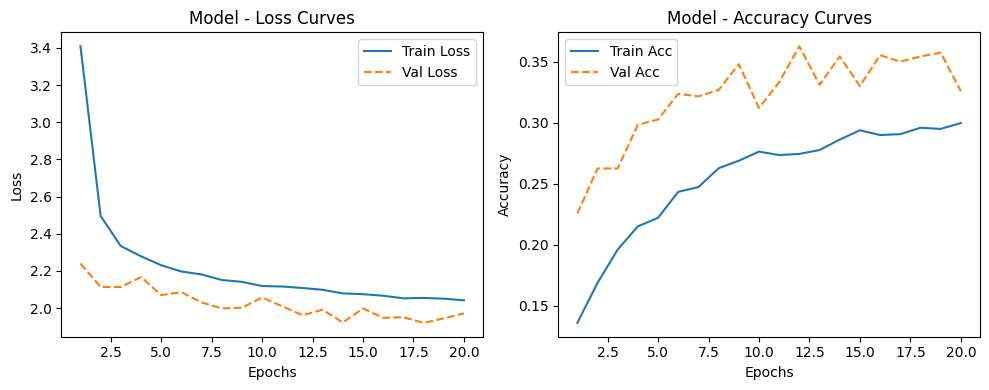

[GAT] Iter 1/6 | New Arch {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'} -> ValAcc=0.3629

[TRAINING] Model=GAT, ArchID=iter2
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.17756660765789534, 'num_heads': 4, 'aggregation': 'sum'}
Epoch 01: TrainLoss=2.6778, ValLoss=2.1449, TrainAcc=0.1716, ValAcc=0.2648
Epoch 02: TrainLoss=2.2977, ValLoss=2.0917, TrainAcc=0.2146, ValAcc=0.2700
Epoch 03: TrainLoss=2.2470, ValLoss=2.0598, TrainAcc=0.2362, ValAcc=0.3154
Epoch 04: TrainLoss=2.1879, ValLoss=2.0561, TrainAcc=0.2539, ValAcc=0.3122
Epoch 05: TrainLoss=2.1524, ValLoss=2.0067, TrainAcc=0.2628, ValAcc=0.3270
Epoch 06: TrainLoss=2.1288, ValLoss=1.9980, TrainAcc=0.2759, ValAcc=0.3165
Epoch 07: TrainLoss=2.1162, ValLoss=1.9923, TrainAcc=0.2662, ValAcc=0.3228
Epoch 08: TrainLoss=2.0956, ValLoss=1.9865, TrainAcc=0.2833, ValAcc=0.3249
Epoch 09: TrainLoss=2.0890, ValLoss=1.9783, TrainAcc=0.2848, ValAcc=0.3281
Epoch 10: TrainLoss=2.075

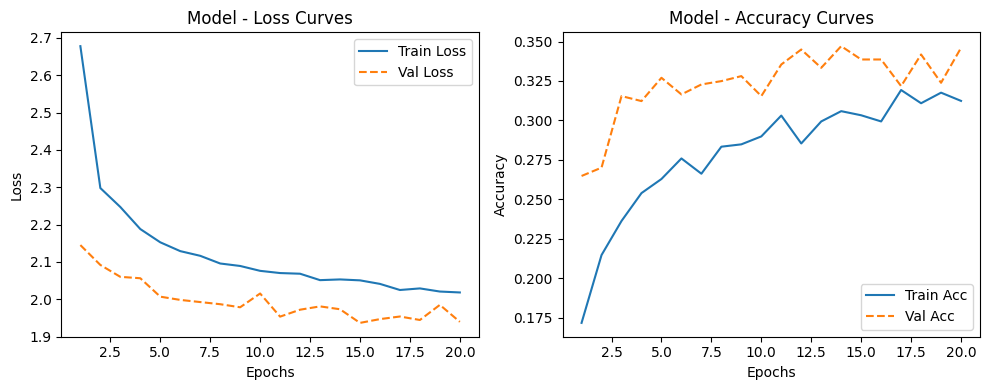

[GAT] Iter 2/6 | New Arch {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.17756660765789534, 'num_heads': 4, 'aggregation': 'sum'} -> ValAcc=0.3470

[TRAINING] Model=GAT, ArchID=iter3
 Config: {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.5678, ValLoss=2.3864, TrainAcc=0.1327, ValAcc=0.2194
Epoch 02: TrainLoss=2.5623, ValLoss=2.2774, TrainAcc=0.1629, ValAcc=0.2342
Epoch 03: TrainLoss=2.3516, ValLoss=2.1739, TrainAcc=0.1927, ValAcc=0.2722
Epoch 04: TrainLoss=2.2767, ValLoss=2.0890, TrainAcc=0.2120, ValAcc=0.2954
Epoch 05: TrainLoss=2.2417, ValLoss=2.0251, TrainAcc=0.2184, ValAcc=0.3122
Epoch 06: TrainLoss=2.2105, ValLoss=2.0238, TrainAcc=0.2345, ValAcc=0.3249
Epoch 07: TrainLoss=2.1836, ValLoss=2.0346, TrainAcc=0.2440, ValAcc=0.3196
Epoch 08: TrainLoss=2.1528, ValLoss=2.0768, TrainAcc=0.2545, ValAcc=0.3228
Epoch 09: TrainLoss=2.1470, ValLoss=2.0033, TrainAcc=0.2595, ValAcc=0.3270
Epoch 10: TrainLoss=2.141

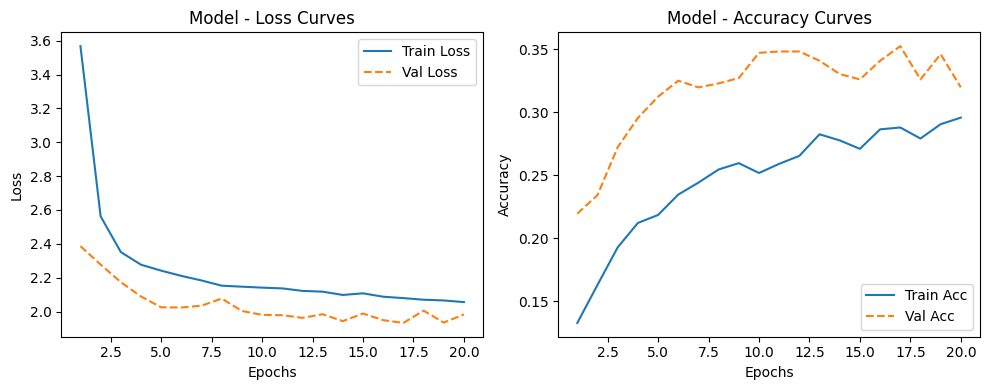

[GAT] Iter 3/6 | New Arch {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'} -> ValAcc=0.3523

[TRAINING] Model=GAT, ArchID=iter4
 Config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'}
Epoch 01: TrainLoss=2.7263, ValLoss=2.1415, TrainAcc=0.1720, ValAcc=0.2785
Epoch 02: TrainLoss=2.3263, ValLoss=2.0947, TrainAcc=0.2139, ValAcc=0.2985
Epoch 03: TrainLoss=2.2378, ValLoss=2.0577, TrainAcc=0.2312, ValAcc=0.3154
Epoch 04: TrainLoss=2.1904, ValLoss=2.0622, TrainAcc=0.2502, ValAcc=0.3017
Epoch 05: TrainLoss=2.1540, ValLoss=2.0420, TrainAcc=0.2628, ValAcc=0.3165
Epoch 06: TrainLoss=2.1368, ValLoss=2.0058, TrainAcc=0.2701, ValAcc=0.3196
Epoch 07: TrainLoss=2.1145, ValLoss=2.0156, TrainAcc=0.2716, ValAcc=0.3249
Epoch 08: TrainLoss=2.0809, ValLoss=1.9997, TrainAcc=0.2887, ValAcc=0.3323
Epoch 09: TrainLoss=2.0827, ValLoss=2.0180, TrainAcc=0.2859, ValAcc=0.3165
Epoch 10: TrainLoss=2.075

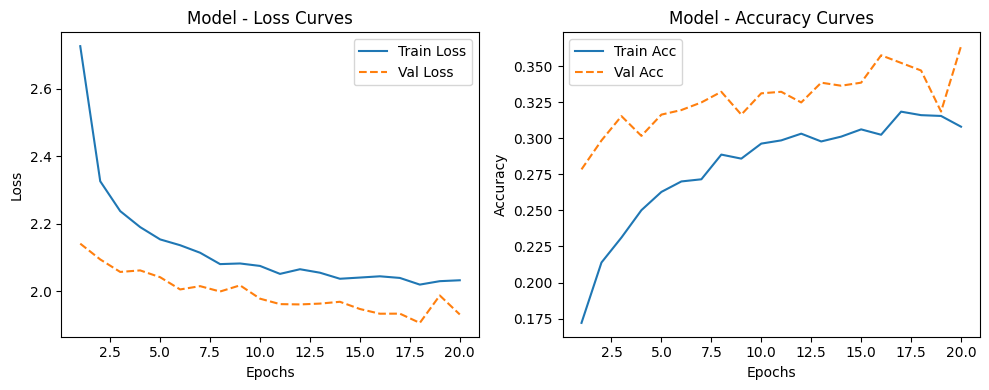

[GAT] Iter 4/6 | New Arch {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'} -> ValAcc=0.3639

[TRAINING] Model=GAT, ArchID=iter5
 Config: {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'}
Epoch 01: TrainLoss=3.1407, ValLoss=2.1538, TrainAcc=0.1454, ValAcc=0.2627
Epoch 02: TrainLoss=2.3937, ValLoss=2.1092, TrainAcc=0.1943, ValAcc=0.2648
Epoch 03: TrainLoss=2.2773, ValLoss=2.1213, TrainAcc=0.2258, ValAcc=0.2932
Epoch 04: TrainLoss=2.2258, ValLoss=2.0749, TrainAcc=0.2375, ValAcc=0.2922
Epoch 05: TrainLoss=2.2032, ValLoss=2.0409, TrainAcc=0.2478, ValAcc=0.3333
Epoch 06: TrainLoss=2.1544, ValLoss=2.0129, TrainAcc=0.2664, ValAcc=0.3259
Epoch 07: TrainLoss=2.1343, ValLoss=2.0454, TrainAcc=0.2720, ValAcc=0.3101
Epoch 08: TrainLoss=2.1365, ValLoss=1.9838, TrainAcc=0.2666, ValAcc=0.3354
Epoch 09: TrainLoss=2.1230, ValLoss=1.9733, TrainAcc=0.2753, ValAcc=0.3502
Epoch 10: TrainLoss=2.122

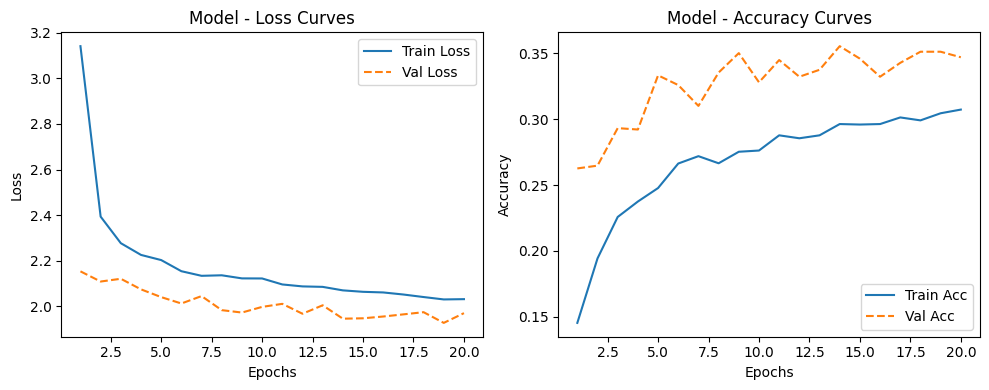

[GAT] Iter 5/6 | New Arch {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'} -> ValAcc=0.3555

[TRAINING] Model=GAT, ArchID=iter6
 Config: {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.2138032437210149, 'num_heads': 2, 'aggregation': 'sum'}
Epoch 01: TrainLoss=4.6674, ValLoss=2.2229, TrainAcc=0.1042, ValAcc=0.2046
Epoch 02: TrainLoss=2.7048, ValLoss=2.2527, TrainAcc=0.1366, ValAcc=0.2352
Epoch 03: TrainLoss=2.4858, ValLoss=2.2987, TrainAcc=0.1616, ValAcc=0.2068
Epoch 04: TrainLoss=2.3694, ValLoss=2.1215, TrainAcc=0.1835, ValAcc=0.2848
Epoch 05: TrainLoss=2.3299, ValLoss=2.2756, TrainAcc=0.1934, ValAcc=0.2068
Epoch 06: TrainLoss=2.2900, ValLoss=2.0864, TrainAcc=0.2001, ValAcc=0.2511
Epoch 07: TrainLoss=2.2463, ValLoss=2.1048, TrainAcc=0.2124, ValAcc=0.2764
Epoch 08: TrainLoss=2.2326, ValLoss=2.1131, TrainAcc=0.2139, ValAcc=0.3302
Epoch 09: TrainLoss=2.2303, ValLoss=2.0730, TrainAcc=0.2217, ValAcc=0.3175
Epoch 10: TrainLoss=2.2021

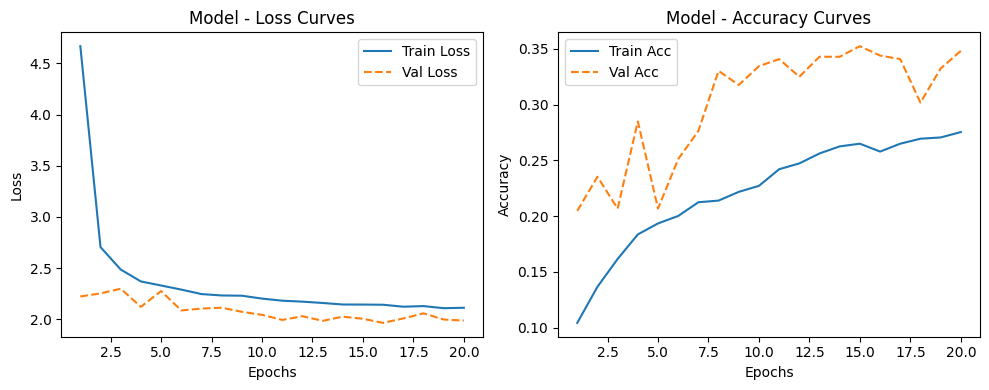

[GAT] Iter 6/6 | New Arch {'hidden_dim': 64, 'num_layers': 5, 'dropout': 0.2138032437210149, 'num_heads': 2, 'aggregation': 'sum'} -> ValAcc=0.3523

=== Best GAT Architecture ===
{'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'} Validation Accuracy: 0.3639

===== BANANAS SEARCH for DiffPool =====

[TRAINING] Model=DiffPool, ArchID=init1
 Config: {'hidden_dim': 128, 'assign_dim': 4, 'embed_dim': 32}
Epoch 01: TrainLoss=2.3840, ValLoss=2.1597, TrainAcc=0.1891, ValAcc=0.2342
Epoch 02: TrainLoss=2.1098, ValLoss=2.0296, TrainAcc=0.2805, ValAcc=0.3154
Epoch 03: TrainLoss=2.0180, ValLoss=1.9688, TrainAcc=0.3135, ValAcc=0.3302
Epoch 04: TrainLoss=1.9682, ValLoss=1.9392, TrainAcc=0.3313, ValAcc=0.3259
Epoch 05: TrainLoss=1.9233, ValLoss=1.8923, TrainAcc=0.3405, ValAcc=0.3502
Epoch 06: TrainLoss=1.8959, ValLoss=1.8877, TrainAcc=0.3541, ValAcc=0.3629
Epoch 07: TrainLoss=1.8726, ValLoss=1.8817, TrainAcc=0.3561, ValAcc=0.3534
Epoch 08: TrainLo

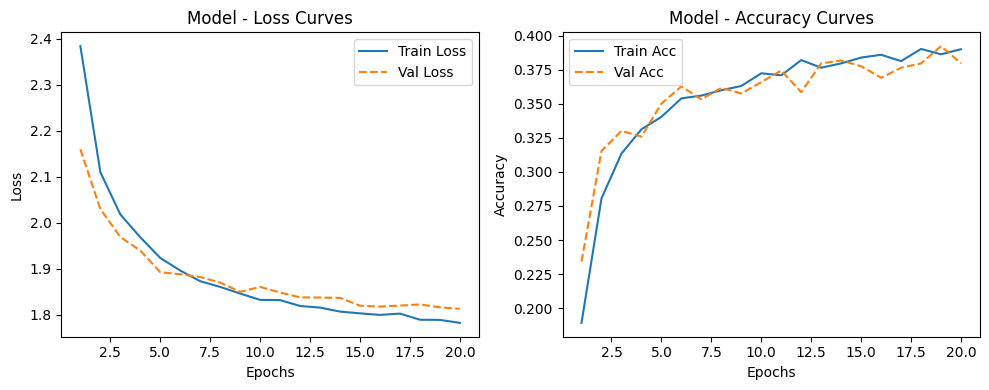


[TRAINING] Model=DiffPool, ArchID=init2
 Config: {'hidden_dim': 32, 'assign_dim': 4, 'embed_dim': 16}
Epoch 01: TrainLoss=2.5476, ValLoss=2.4697, TrainAcc=0.1108, ValAcc=0.2184
Epoch 02: TrainLoss=2.3326, ValLoss=2.1767, TrainAcc=0.2059, ValAcc=0.2321
Epoch 03: TrainLoss=2.1854, ValLoss=2.0959, TrainAcc=0.2370, ValAcc=0.2722
Epoch 04: TrainLoss=2.1319, ValLoss=2.0545, TrainAcc=0.2656, ValAcc=0.3038
Epoch 05: TrainLoss=2.0900, ValLoss=2.0137, TrainAcc=0.2908, ValAcc=0.3101
Epoch 06: TrainLoss=2.0626, ValLoss=1.9951, TrainAcc=0.2975, ValAcc=0.3112
Epoch 07: TrainLoss=2.0365, ValLoss=1.9737, TrainAcc=0.3112, ValAcc=0.3217
Epoch 08: TrainLoss=2.0087, ValLoss=1.9632, TrainAcc=0.3243, ValAcc=0.3101
Epoch 09: TrainLoss=1.9932, ValLoss=1.9521, TrainAcc=0.3219, ValAcc=0.3238
Epoch 10: TrainLoss=1.9677, ValLoss=1.9295, TrainAcc=0.3289, ValAcc=0.3133
Epoch 11: TrainLoss=1.9605, ValLoss=1.9218, TrainAcc=0.3377, ValAcc=0.3333
Epoch 12: TrainLoss=1.9463, ValLoss=1.9051, TrainAcc=0.3382, ValAcc=0.35

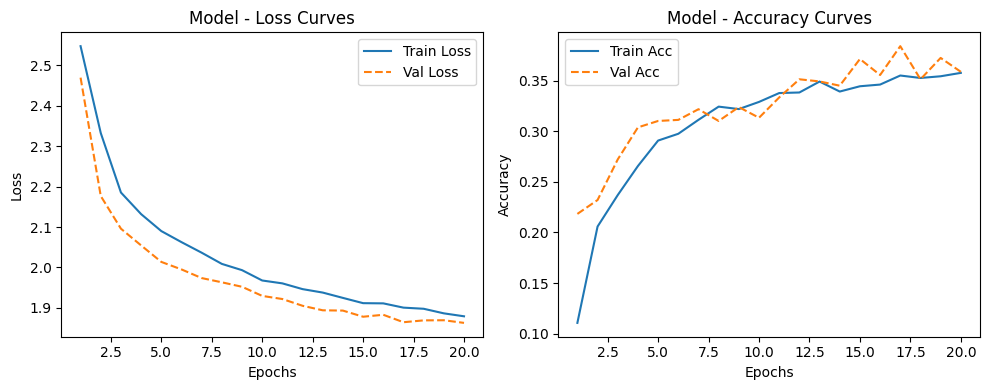


[TRAINING] Model=DiffPool, ArchID=init3
 Config: {'hidden_dim': 32, 'assign_dim': 16, 'embed_dim': 32}
Epoch 01: TrainLoss=2.5041, ValLoss=2.3409, TrainAcc=0.1357, ValAcc=0.1973
Epoch 02: TrainLoss=2.2377, ValLoss=2.1036, TrainAcc=0.2360, ValAcc=0.2722
Epoch 03: TrainLoss=2.1161, ValLoss=2.0307, TrainAcc=0.2772, ValAcc=0.3080
Epoch 04: TrainLoss=2.0649, ValLoss=1.9910, TrainAcc=0.2947, ValAcc=0.3080
Epoch 05: TrainLoss=2.0230, ValLoss=1.9622, TrainAcc=0.3105, ValAcc=0.3175
Epoch 06: TrainLoss=1.9980, ValLoss=1.9485, TrainAcc=0.3187, ValAcc=0.3238
Epoch 07: TrainLoss=1.9703, ValLoss=1.9326, TrainAcc=0.3233, ValAcc=0.3312
Epoch 08: TrainLoss=1.9514, ValLoss=1.9136, TrainAcc=0.3341, ValAcc=0.3281
Epoch 09: TrainLoss=1.9353, ValLoss=1.9006, TrainAcc=0.3380, ValAcc=0.3460
Epoch 10: TrainLoss=1.9230, ValLoss=1.8837, TrainAcc=0.3384, ValAcc=0.3703
Epoch 11: TrainLoss=1.9085, ValLoss=1.8807, TrainAcc=0.3446, ValAcc=0.3534
Epoch 12: TrainLoss=1.9037, ValLoss=1.8742, TrainAcc=0.3380, ValAcc=0.3

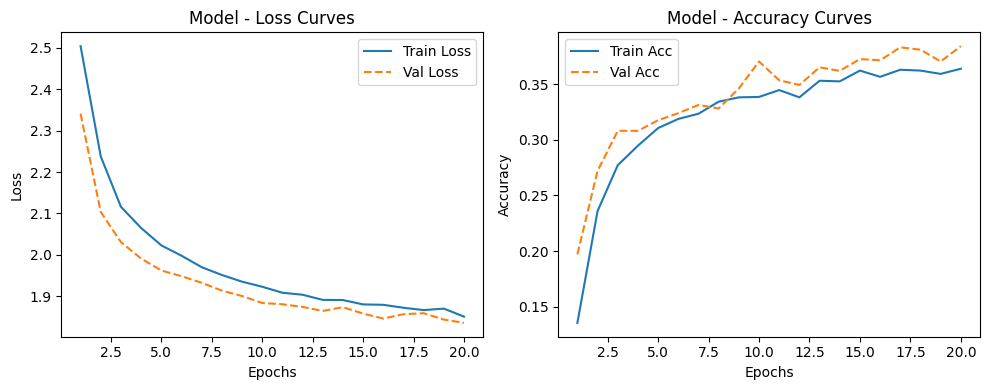


[TRAINING] Model=DiffPool, ArchID=iter1
 Config: {'hidden_dim': 128, 'assign_dim': 4, 'embed_dim': 64}
Epoch 01: TrainLoss=2.3492, ValLoss=2.1130, TrainAcc=0.1917, ValAcc=0.3049
Epoch 02: TrainLoss=2.0655, ValLoss=1.9916, TrainAcc=0.3017, ValAcc=0.3291
Epoch 03: TrainLoss=1.9833, ValLoss=1.9427, TrainAcc=0.3213, ValAcc=0.3165
Epoch 04: TrainLoss=1.9214, ValLoss=1.8993, TrainAcc=0.3416, ValAcc=0.3439
Epoch 05: TrainLoss=1.8905, ValLoss=1.8942, TrainAcc=0.3498, ValAcc=0.3449
Epoch 06: TrainLoss=1.8692, ValLoss=1.8586, TrainAcc=0.3563, ValAcc=0.3745
Epoch 07: TrainLoss=1.8506, ValLoss=1.8608, TrainAcc=0.3611, ValAcc=0.3544
Epoch 08: TrainLoss=1.8429, ValLoss=1.8474, TrainAcc=0.3695, ValAcc=0.3555
Epoch 09: TrainLoss=1.8347, ValLoss=1.8564, TrainAcc=0.3688, ValAcc=0.3745
Epoch 10: TrainLoss=1.8243, ValLoss=1.8536, TrainAcc=0.3766, ValAcc=0.3892
Epoch 11: TrainLoss=1.8089, ValLoss=1.8380, TrainAcc=0.3783, ValAcc=0.3755
Epoch 12: TrainLoss=1.8082, ValLoss=1.8369, TrainAcc=0.3768, ValAcc=0.3

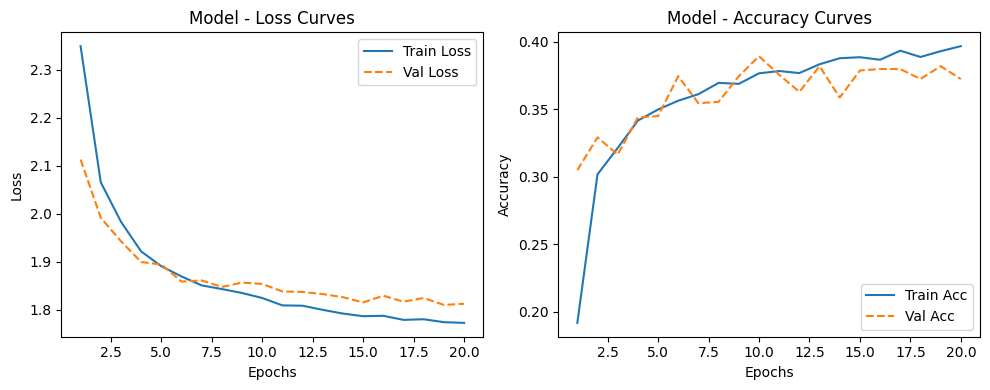

[DiffPool] Iter 1/6 | New Arch {'hidden_dim': 128, 'assign_dim': 4, 'embed_dim': 64} -> ValAcc=0.3892

[TRAINING] Model=DiffPool, ArchID=iter2
 Config: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64}
Epoch 01: TrainLoss=2.3771, ValLoss=2.1149, TrainAcc=0.1815, ValAcc=0.2700
Epoch 02: TrainLoss=2.0805, ValLoss=2.0074, TrainAcc=0.3006, ValAcc=0.3133
Epoch 03: TrainLoss=1.9873, ValLoss=1.9455, TrainAcc=0.3291, ValAcc=0.3333
Epoch 04: TrainLoss=1.9257, ValLoss=1.9171, TrainAcc=0.3420, ValAcc=0.3439
Epoch 05: TrainLoss=1.8860, ValLoss=1.8829, TrainAcc=0.3609, ValAcc=0.3534
Epoch 06: TrainLoss=1.8590, ValLoss=1.8693, TrainAcc=0.3636, ValAcc=0.3439
Epoch 07: TrainLoss=1.8532, ValLoss=1.8426, TrainAcc=0.3690, ValAcc=0.3618
Epoch 08: TrainLoss=1.8371, ValLoss=1.8420, TrainAcc=0.3636, ValAcc=0.3776
Epoch 09: TrainLoss=1.8297, ValLoss=1.8343, TrainAcc=0.3738, ValAcc=0.3692
Epoch 10: TrainLoss=1.8146, ValLoss=1.8312, TrainAcc=0.3857, ValAcc=0.3945
Epoch 11: TrainLoss=1.8027, ValLoss=1.8428,

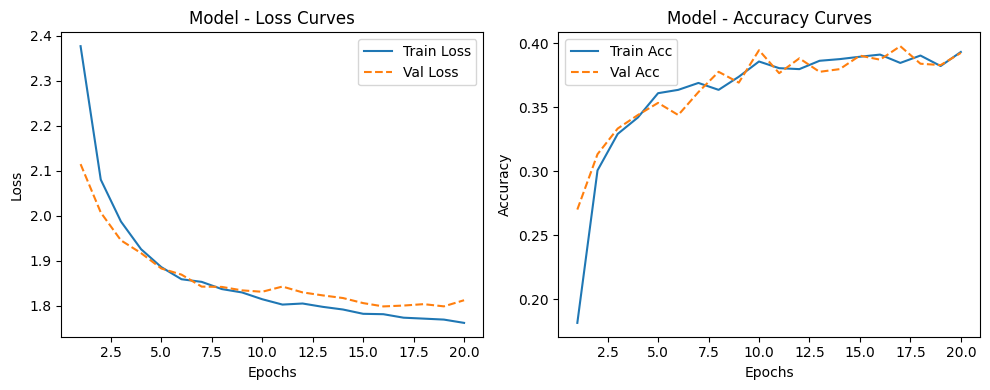

[DiffPool] Iter 2/6 | New Arch {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64} -> ValAcc=0.3977

[TRAINING] Model=DiffPool, ArchID=iter3
 Config: {'hidden_dim': 32, 'assign_dim': 16, 'embed_dim': 64}
Epoch 01: TrainLoss=2.4398, ValLoss=2.2333, TrainAcc=0.1458, ValAcc=0.1994
Epoch 02: TrainLoss=2.1879, ValLoss=2.0854, TrainAcc=0.2306, ValAcc=0.2774
Epoch 03: TrainLoss=2.0991, ValLoss=2.0231, TrainAcc=0.2768, ValAcc=0.3017
Epoch 04: TrainLoss=2.0430, ValLoss=1.9742, TrainAcc=0.3017, ValAcc=0.3270
Epoch 05: TrainLoss=1.9911, ValLoss=1.9292, TrainAcc=0.3254, ValAcc=0.3312
Epoch 06: TrainLoss=1.9541, ValLoss=1.9008, TrainAcc=0.3299, ValAcc=0.3608
Epoch 07: TrainLoss=1.9342, ValLoss=1.9002, TrainAcc=0.3449, ValAcc=0.3534
Epoch 08: TrainLoss=1.9106, ValLoss=1.8823, TrainAcc=0.3438, ValAcc=0.3460
Epoch 09: TrainLoss=1.9016, ValLoss=1.8746, TrainAcc=0.3464, ValAcc=0.3618
Epoch 10: TrainLoss=1.8968, ValLoss=1.8719, TrainAcc=0.3518, ValAcc=0.3681
Epoch 11: TrainLoss=1.8841, ValLoss=1.8559,

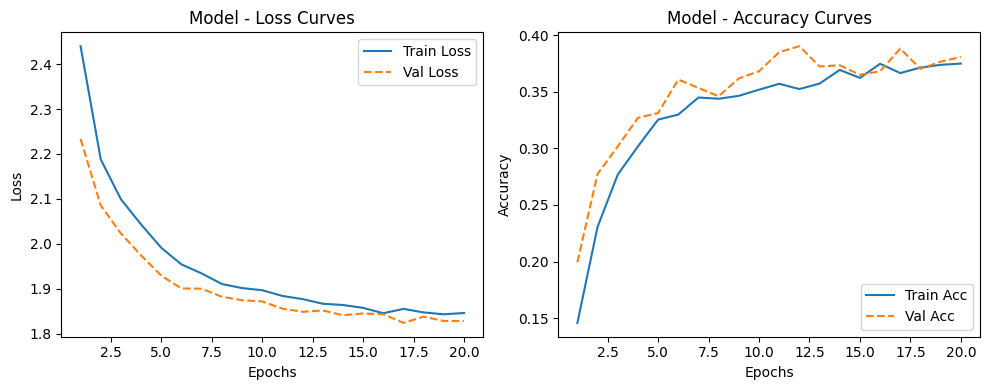

[DiffPool] Iter 3/6 | New Arch {'hidden_dim': 32, 'assign_dim': 16, 'embed_dim': 64} -> ValAcc=0.3903

[TRAINING] Model=DiffPool, ArchID=iter4
 Config: {'hidden_dim': 64, 'assign_dim': 16, 'embed_dim': 64}
Epoch 01: TrainLoss=2.4108, ValLoss=2.1682, TrainAcc=0.1687, ValAcc=0.2711
Epoch 02: TrainLoss=2.1275, ValLoss=2.0081, TrainAcc=0.2800, ValAcc=0.3165
Epoch 03: TrainLoss=2.0248, ValLoss=1.9517, TrainAcc=0.3137, ValAcc=0.3080
Epoch 04: TrainLoss=1.9720, ValLoss=1.9249, TrainAcc=0.3325, ValAcc=0.3492
Epoch 05: TrainLoss=1.9373, ValLoss=1.9086, TrainAcc=0.3395, ValAcc=0.3544
Epoch 06: TrainLoss=1.9064, ValLoss=1.8815, TrainAcc=0.3505, ValAcc=0.3576
Epoch 07: TrainLoss=1.8871, ValLoss=1.8695, TrainAcc=0.3548, ValAcc=0.3460
Epoch 08: TrainLoss=1.8691, ValLoss=1.8716, TrainAcc=0.3582, ValAcc=0.3576
Epoch 09: TrainLoss=1.8557, ValLoss=1.8474, TrainAcc=0.3690, ValAcc=0.3681
Epoch 10: TrainLoss=1.8518, ValLoss=1.8413, TrainAcc=0.3645, ValAcc=0.3776
Epoch 11: TrainLoss=1.8471, ValLoss=1.8414, 

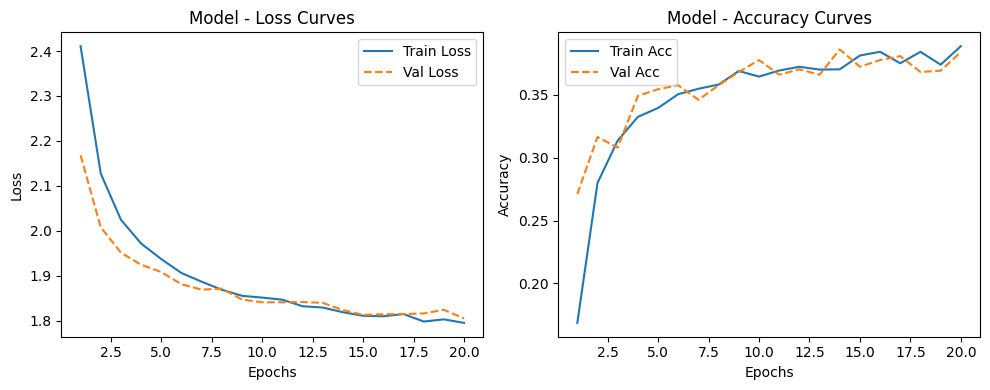

[DiffPool] Iter 4/6 | New Arch {'hidden_dim': 64, 'assign_dim': 16, 'embed_dim': 64} -> ValAcc=0.3861

[TRAINING] Model=DiffPool, ArchID=iter5
 Config: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64}
Epoch 01: TrainLoss=2.3628, ValLoss=2.1151, TrainAcc=0.1930, ValAcc=0.2511
Epoch 02: TrainLoss=2.0925, ValLoss=2.0213, TrainAcc=0.2872, ValAcc=0.2932
Epoch 03: TrainLoss=1.9973, ValLoss=1.9424, TrainAcc=0.3271, ValAcc=0.3386
Epoch 04: TrainLoss=1.9295, ValLoss=1.9088, TrainAcc=0.3448, ValAcc=0.3650
Epoch 05: TrainLoss=1.8841, ValLoss=1.8714, TrainAcc=0.3535, ValAcc=0.3597
Epoch 06: TrainLoss=1.8644, ValLoss=1.8435, TrainAcc=0.3669, ValAcc=0.3819
Epoch 07: TrainLoss=1.8490, ValLoss=1.8566, TrainAcc=0.3604, ValAcc=0.3597
Epoch 08: TrainLoss=1.8311, ValLoss=1.8328, TrainAcc=0.3673, ValAcc=0.3892
Epoch 09: TrainLoss=1.8216, ValLoss=1.8487, TrainAcc=0.3723, ValAcc=0.3776
Epoch 10: TrainLoss=1.8146, ValLoss=1.8157, TrainAcc=0.3753, ValAcc=0.3924
Epoch 11: TrainLoss=1.8082, ValLoss=1.8453,

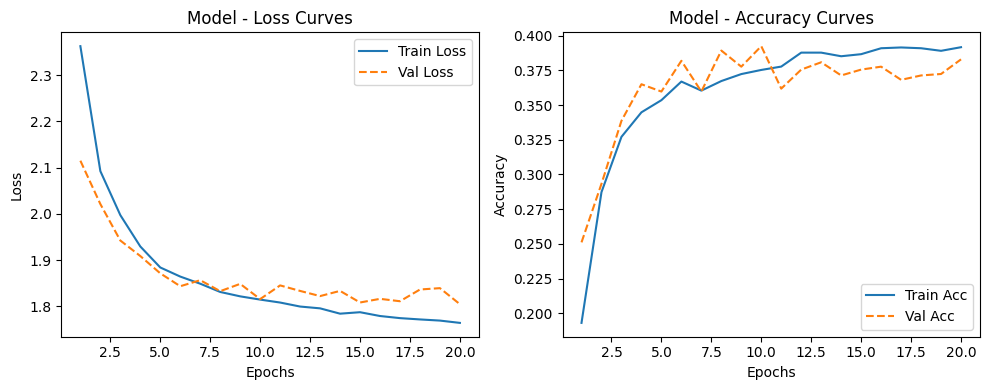

[DiffPool] Iter 5/6 | New Arch {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64} -> ValAcc=0.3924

[TRAINING] Model=DiffPool, ArchID=iter6
 Config: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 16}
Epoch 01: TrainLoss=2.4680, ValLoss=2.2655, TrainAcc=0.1582, ValAcc=0.2542
Epoch 02: TrainLoss=2.1692, ValLoss=2.0626, TrainAcc=0.2740, ValAcc=0.2806
Epoch 03: TrainLoss=2.0780, ValLoss=2.0178, TrainAcc=0.3006, ValAcc=0.3091
Epoch 04: TrainLoss=2.0303, ValLoss=2.0075, TrainAcc=0.3217, ValAcc=0.3312
Epoch 05: TrainLoss=1.9971, ValLoss=1.9561, TrainAcc=0.3373, ValAcc=0.3376
Epoch 06: TrainLoss=1.9716, ValLoss=1.9409, TrainAcc=0.3416, ValAcc=0.3460
Epoch 07: TrainLoss=1.9373, ValLoss=1.9251, TrainAcc=0.3481, ValAcc=0.3418
Epoch 08: TrainLoss=1.9188, ValLoss=1.9019, TrainAcc=0.3531, ValAcc=0.3692
Epoch 09: TrainLoss=1.8924, ValLoss=1.8960, TrainAcc=0.3535, ValAcc=0.3629
Epoch 10: TrainLoss=1.8757, ValLoss=1.8988, TrainAcc=0.3583, ValAcc=0.3660
Epoch 11: TrainLoss=1.8623, ValLoss=1.8790

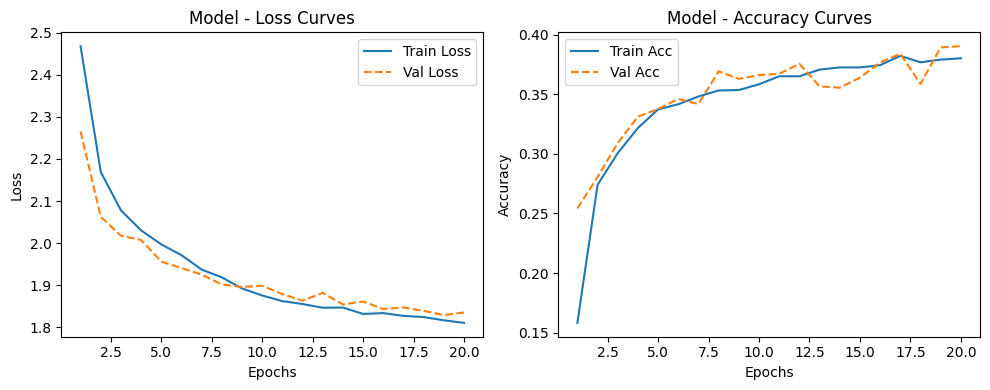

[DiffPool] Iter 6/6 | New Arch {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 16} -> ValAcc=0.3903

=== Best DiffPool Architecture ===
{'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64} Validation Accuracy: 0.3977

--- Best Architectures Found ---
Best GIN Architecture: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'}
Best GAT Architecture: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'}
Best DiffPool Architecture: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64}
BANANAS architecture search completed for GIN, GAT, GCN, and DiffPool models.


In [ ]:
# Arch search spaces
arch_space_gin = {
    "hidden_dim": [32, 64, 128],
    "num_layers": [2, 3, 4, 5],
    "dropout": [0.0, 0.25, 0.5],
    "aggregation": ['sum', 'mean']
}
arch_space_gat = {
    "hidden_dim": [32, 64],
    "num_layers": [2, 3, 4, 5],
    "dropout": [0.0, 0.25, 0.5],
    "num_heads": [2, 4, 8],
    "aggregation": ['sum', 'mean']
}
arch_space_diff = {
    "hidden_dim": [32, 64, 128],
    "assign_dim": [4, 8, 16],
    "embed_dim": [16, 32, 64]
}

BANANAS_CONFIG = {
        'num_init': 3,
        'num_iter': 6,
        'short_epochs': 20,
        'candidates_per_iter': 100,
        'surrogate_epochs': 50,
        'surrogate_n_models': 10,
        'surrogate_lr': 1e-3,
        'batch_size': 16,
        'short_lr': 1e-3,
        'short_wd': 5e-4,
        'ei_xi': 0.01
    }

# BANANAS architecture search for each model (validation accuracy objective)
print("Running BANANAS architecture search for GIN, GAT, and GCN models...")

# 1. Run BANANAS architecture search per model
best_arch_gin, _ = bananas_search(model_name='GIN', model_class=GINNet, arch_space=arch_space_gin, train_dataset=train_dataset, config=BANANAS_CONFIG)
best_arch_gat, _ = bananas_search(model_name='GAT', model_class=GATNet, arch_space=arch_space_gat, train_dataset=train_dataset, config=BANANAS_CONFIG)
# Note: DiffPool does not have the 'aggregation' parameter, so its arch_space_diff remains unchanged.
best_arch_diff, _ = bananas_search(model_name='DiffPool', model_class=DiffPoolNet, arch_space=arch_space_diff, train_dataset=train_dataset, config=BANANAS_CONFIG)

# 4. Print the best architectures found
print("\n--- Best Architectures Found ---")
print("Best GIN Architecture:", best_arch_gin)
print("Best GAT Architecture:", best_arch_gat)
print("Best DiffPool Architecture:", best_arch_diff)

print("BANANAS architecture search completed for GIN, GAT, GCN, and DiffPool models.")

**MANGO Hyperparameter Tuning**  
Mango is a python library to find the optimal hyperparameters for machine learning classifiers. Mango enables parallel optimization over complex search spaces of continuous/discrete/categorical values.  

In [ ]:
# === Universal type cleaner ===
def clean_arch_config(arch_config):
    """Convert all numeric values to proper Python types for model building."""
    cleaned = {}
    for k, v in arch_config.items():
        if isinstance(v, (list, np.ndarray)):
            # just take first if accidentally a list or np array
            v = v[0] if len(v) > 0 else v
        if isinstance(v, (np.integer, int)):
            cleaned[k] = int(v)
        elif isinstance(v, (np.floating, float)):
            # if e.g. 3.0 → 3
            cleaned[k] = int(v) if float(v).is_integer() else float(v)
        else:
            cleaned[k] = v
    return cleaned

# === Mango objective factory ===
import numpy as np
from collections import Counter

# Calculate class counts for class weighting
train_labels_counts = Counter(train_labels_int) # Use the new labels list
# Ensure all classes from 0 to num_classes-1 are present, filling with 0 if not
class_counts = torch.tensor([train_labels_counts.get(i, 0) for i in range(num_classes)], dtype=torch.float32)

def make_mango_objective(model_cls, arch_config, train_dataset,
                         num_classes, device,
                         short_epochs=10):
    """
    Objective function for Mango tuning.
    Returns 1 - validation_accuracy to be minimized.
    """
    @scheduler.serial
    def objective(**params):
        # params: a dict provided by Mango for this trial
        # get search params
        lr = float(params.get('lr', 1e-3))
        wd = float(params.get('weight_decay', 5e-4))
        bs = int(params.get('batch_size', 64))
        grad_clip_norm = float(params.get('grad_clip_norm', 0.0))
        class_weights_type = params.get('class_weights_type', 'none')

        print(f"\nParams: lr={lr}, weight_decay={wd}, batch_size={bs}, grad_clip_norm={grad_clip_norm}, class_weights_type={class_weights_type}")

        # DataLoaders local to this call
        train_loader = GraphDataLoader(train_subset, batch_size=bs, shuffle=True)
        val_loader = GraphDataLoader(val_subset, batch_size=bs, shuffle=False)

        # clean config to safe numeric types
        arch_cfg_clean = clean_arch_config(arch_config)

        # build model
        in_feats = train_dataset[0][0].ndata['feat'].shape[1] # Use updated train_dataset_new
        model = _build_model_from_cls(model_cls,
                                      arch_cfg_clean,
                                      in_feats,
                                      num_classes,
                                      device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

        # Initialize LR scheduler
        # Using ReduceLROnPlateau as it's common for validation-based scheduling
        lr_plateau_scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=False)

        # Prepare class weights based on chosen strategy
        current_class_weights = None
        if class_weights_type == 'inverse_freq':
            # Inverse frequency weighting: 1 / frequency
            weights = 1.0 / (class_counts + 1e-9) # Add small epsilon to avoid division by zero
            current_class_weights = weights / weights.sum() * num_classes # Normalize weights
        elif class_weights_type == 'inverse_sqrt_freq':
            # Inverse square root frequency weighting: 1 / sqrt(frequency)
            weights = 1.0 / torch.sqrt(class_counts + 1e-9)
            current_class_weights = weights / weights.sum() * num_classes # Normalize weights
        # For 'none', current_class_weights remains None, so nn.CrossEntropyLoss will be used without weights

        # Use current_class_weights for loss_fn
        loss_fn = nn.CrossEntropyLoss(weight=current_class_weights.to(device)) if current_class_weights is not None else nn.CrossEntropyLoss()

        # quick training
        model, history = train_model(
                          model, train_loader, val_loader, loss_fn, optimizer,
                          device, num_epochs=short_epochs,
                          scheduler=lr_plateau_scheduler, # Pass scheduler
                          grad_clip_norm=grad_clip_norm,    # Pass grad_clip_norm
                          class_weights=current_class_weights # Pass class_weights explicitly
                          )

        best_val_acc = max(history.get('val_acc', [0.0]))

        # Mango minimizes by default → we return 1 - accuracy
        return 1.0 - float(best_val_acc) # minimize (lower is better)

    return objective

print("MANGO_SPACE updated and make_mango_objective function redefined with new parameters.")

def run_mango_tuning(model_cls, best_arch, train_dataset, mango_space=None,
                     num_iter=10, short_epochs=10, plot_convergence=True):
    """
    Run Mango tuner and return best hyperparameters dict.
    - model_cls: model class (GINNet, GATNet, DiffPoolNet)
    - best_arch: architecture dict found by BANANAS (used to build model)
    - train_dataset: the Dataset object (train only)
    - mango_space: dict param -> list (categorical)
    """
    print(f"\n===== MANGO Hyperparameter Tuning for {model_cls.__name__} =====")

    arch_cfg_clean = clean_arch_config(best_arch)
    print("Best Architecture:", arch_cfg_clean)

    objective = make_mango_objective(
        model_cls=model_cls,
        arch_config=arch_cfg_clean,
        train_dataset=train_dataset,
        num_classes=num_classes,
        device=device,
        short_epochs=short_epochs
    )

    # prepare param space
    param_space = mango_space

    # Mango Config
    print(f"\n[MANGO] Initial random trials = {2} / Total trials = {num_iter}")

    # Configure the Mango tuner
    conf = {
        'num_iteration': num_iter,
        'initial_random': 2,
        'domain_size': 2000,
        'batch_size': 1
    }

    # Initialize and run Tuner
    tuner = Tuner(param_space, objective, conf)
    results = tuner.minimize()
    print(f"\n[MANGO] Best hyperparameters for {model_cls.__name__}: {results['best_params']}")

    # Final best params
    best_params = results.get('best_params')
    best_obj = results.get('best_objective')
    best_acc = 1 - best_obj

    print(f"\n[MANGO] {model_cls.__name__}: ")
    print(f"Best params: {best_params}")
    print(f"Best val accuracy: {best_acc:.4f}")

    # Optional convergence plot
    obj_vals = results.get('objective_values')
    if plot_convergence and obj_vals is not None:
        accs = [1 - float(x) for x in obj_vals]
        plt.figure(figsize=(6,4))
        plt.plot(accs, marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("Validation Accuracy")
        plt.title(f"MANGO Convergence - {model_cls.__name__}")
        plt.grid(True)
        plt.show()

    return best_params, results

MANGO_SPACE updated and make_mango_objective function redefined with new parameters.


### Run Mango tuning for hyperparameter tuning
Executing MANGO hyperparameter tuning for the models using the best_arch found by BANANAS and the MANGO_SPACE.   
This will find the optimal training hyperparameters including **learning rate**, **weight decay**, **batch size**, **gradient clipping norm**, and **class weighting** strategy.


===== MANGO Hyperparameter Tuning for GINNet =====
Best Architecture: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'}

[MANGO] Initial random trials = 2 / Total trials = 10

Params: lr=0.001, weight_decay=0.001, batch_size=32, grad_clip_norm=0.5, class_weights_type=none
Epoch 01: TrainLoss=2.1291, ValLoss=1.8958, TrainAcc=0.2746, ValAcc=0.3586
Epoch 02: TrainLoss=1.9160, ValLoss=1.8871, TrainAcc=0.3477, ValAcc=0.3534
Epoch 03: TrainLoss=1.8606, ValLoss=1.8254, TrainAcc=0.3613, ValAcc=0.3892
Epoch 04: TrainLoss=1.8467, ValLoss=1.8140, TrainAcc=0.3656, ValAcc=0.3861
Epoch 05: TrainLoss=1.8312, ValLoss=1.8675, TrainAcc=0.3704, ValAcc=0.3586
Epoch 06: TrainLoss=1.8278, ValLoss=1.7971, TrainAcc=0.3736, ValAcc=0.3840
Epoch 07: TrainLoss=1.8144, ValLoss=1.8292, TrainAcc=0.3850, ValAcc=0.3956
Epoch 08: TrainLoss=1.8023, ValLoss=1.8088, TrainAcc=0.3872, ValAcc=0.3745
Epoch 09: TrainLoss=1.8065, ValLoss=1.7806, TrainAcc=0.3868, ValAcc=0.4030
Epoch 10:

  0%|          | 0/10 [00:00<?, ?it/s]


Params: lr=0.0005, weight_decay=0.0005, batch_size=32, grad_clip_norm=5.0, class_weights_type=inverse_freq
Epoch 01: TrainLoss=2.1943, ValLoss=1.9394, TrainAcc=0.2623, ValAcc=0.3671
Epoch 02: TrainLoss=1.9452, ValLoss=1.9075, TrainAcc=0.3479, ValAcc=0.3639
Epoch 03: TrainLoss=1.8730, ValLoss=1.8462, TrainAcc=0.3531, ValAcc=0.3850
Epoch 04: TrainLoss=1.8576, ValLoss=1.8028, TrainAcc=0.3626, ValAcc=0.3829
Epoch 05: TrainLoss=1.8284, ValLoss=1.8002, TrainAcc=0.3688, ValAcc=0.3966
Epoch 06: TrainLoss=1.8079, ValLoss=1.7927, TrainAcc=0.3855, ValAcc=0.4093
Epoch 07: TrainLoss=1.7834, ValLoss=1.7747, TrainAcc=0.3933, ValAcc=0.4019
Epoch 08: TrainLoss=1.7755, ValLoss=1.7774, TrainAcc=0.4023, ValAcc=0.4114
Epoch 09: TrainLoss=1.7604, ValLoss=1.7560, TrainAcc=0.4058, ValAcc=0.4230
Epoch 10: TrainLoss=1.7549, ValLoss=1.7740, TrainAcc=0.4038, ValAcc=0.3987

Params: lr=0.005, weight_decay=0.0005, batch_size=32, grad_clip_norm=5.0, class_weights_type=none
Epoch 01: TrainLoss=2.0717, ValLoss=1.9302,

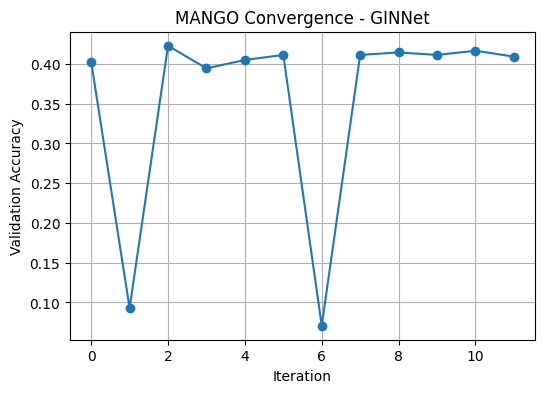


===== MANGO Hyperparameter Tuning for GATNet =====
Best Architecture: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'}

[MANGO] Initial random trials = 2 / Total trials = 10

Params: lr=0.001, weight_decay=1e-05, batch_size=32, grad_clip_norm=0.5, class_weights_type=none
Epoch 01: TrainLoss=2.8000, ValLoss=2.1711, TrainAcc=0.1707, ValAcc=0.2542
Epoch 02: TrainLoss=2.3502, ValLoss=2.0936, TrainAcc=0.2079, ValAcc=0.2774
Epoch 03: TrainLoss=2.2338, ValLoss=2.0892, TrainAcc=0.2375, ValAcc=0.2922
Epoch 04: TrainLoss=2.2178, ValLoss=2.0845, TrainAcc=0.2416, ValAcc=0.2996
Epoch 05: TrainLoss=2.1638, ValLoss=2.0495, TrainAcc=0.2623, ValAcc=0.3186
Epoch 06: TrainLoss=2.1607, ValLoss=2.0394, TrainAcc=0.2610, ValAcc=0.3112
Epoch 07: TrainLoss=2.1379, ValLoss=2.0140, TrainAcc=0.2710, ValAcc=0.3238
Epoch 08: TrainLoss=2.1070, ValLoss=2.0111, TrainAcc=0.2829, ValAcc=0.3333
Epoch 09: TrainLoss=2.1095, ValLoss=1.9985, TrainAcc=0.2880, ValAcc=0.

  0%|          | 0/10 [00:00<?, ?it/s]


Params: lr=0.005, weight_decay=0.0005, batch_size=64, grad_clip_norm=5.0, class_weights_type=none
Epoch 01: TrainLoss=2.5907, ValLoss=2.1096, TrainAcc=0.1949, ValAcc=0.3006
Epoch 02: TrainLoss=2.2159, ValLoss=2.0749, TrainAcc=0.2407, ValAcc=0.2932
Epoch 03: TrainLoss=2.1727, ValLoss=2.0462, TrainAcc=0.2578, ValAcc=0.3091
Epoch 04: TrainLoss=2.1515, ValLoss=2.0175, TrainAcc=0.2669, ValAcc=0.3175
Epoch 05: TrainLoss=2.1313, ValLoss=2.0023, TrainAcc=0.2829, ValAcc=0.3249
Epoch 06: TrainLoss=2.1260, ValLoss=1.9787, TrainAcc=0.2856, ValAcc=0.3439
Epoch 07: TrainLoss=2.0887, ValLoss=1.9724, TrainAcc=0.2954, ValAcc=0.3376
Epoch 08: TrainLoss=2.0905, ValLoss=1.9856, TrainAcc=0.2926, ValAcc=0.3270
Epoch 09: TrainLoss=2.0722, ValLoss=1.9739, TrainAcc=0.2930, ValAcc=0.3376
Epoch 10: TrainLoss=2.0689, ValLoss=1.9818, TrainAcc=0.3077, ValAcc=0.3418

Params: lr=0.0005, weight_decay=0.0005, batch_size=32, grad_clip_norm=0.0, class_weights_type=inverse_sqrt_freq
Epoch 01: TrainLoss=3.1876, ValLoss=2.

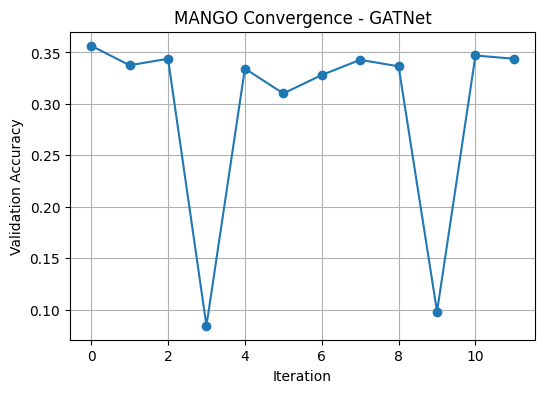


===== MANGO Hyperparameter Tuning for DiffPoolNet =====
Best Architecture: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64}

[MANGO] Initial random trials = 2 / Total trials = 10

Params: lr=0.0005, weight_decay=0.001, batch_size=32, grad_clip_norm=5.0, class_weights_type=none
Epoch 01: TrainLoss=2.5268, ValLoss=2.4358, TrainAcc=0.1480, ValAcc=0.1920
Epoch 02: TrainLoss=2.3106, ValLoss=2.1945, TrainAcc=0.2111, ValAcc=0.2236
Epoch 03: TrainLoss=2.1605, ValLoss=2.1022, TrainAcc=0.2563, ValAcc=0.2658
Epoch 04: TrainLoss=2.0994, ValLoss=2.0476, TrainAcc=0.2895, ValAcc=0.2911
Epoch 05: TrainLoss=2.0591, ValLoss=2.0172, TrainAcc=0.3146, ValAcc=0.3112
Epoch 06: TrainLoss=2.0243, ValLoss=1.9926, TrainAcc=0.3194, ValAcc=0.3207
Epoch 07: TrainLoss=1.9943, ValLoss=1.9773, TrainAcc=0.3276, ValAcc=0.3165
Epoch 08: TrainLoss=1.9742, ValLoss=1.9553, TrainAcc=0.3431, ValAcc=0.3354
Epoch 09: TrainLoss=1.9496, ValLoss=1.9346, TrainAcc=0.3449, ValAcc=0.3407
Epoch 10: TrainLoss=1.9292, ValLoss=1.92

  0%|          | 0/10 [00:00<?, ?it/s]


Params: lr=0.001, weight_decay=0.0005, batch_size=64, grad_clip_norm=1.0, class_weights_type=none
Epoch 01: TrainLoss=2.5012, ValLoss=2.3752, TrainAcc=0.1623, ValAcc=0.1698
Epoch 02: TrainLoss=2.2536, ValLoss=2.1285, TrainAcc=0.2210, ValAcc=0.2700
Epoch 03: TrainLoss=2.1276, ValLoss=2.0674, TrainAcc=0.2766, ValAcc=0.2869
Epoch 04: TrainLoss=2.0686, ValLoss=2.0083, TrainAcc=0.2984, ValAcc=0.3207
Epoch 05: TrainLoss=2.0214, ValLoss=1.9724, TrainAcc=0.3207, ValAcc=0.3196
Epoch 06: TrainLoss=1.9806, ValLoss=1.9449, TrainAcc=0.3282, ValAcc=0.3386
Epoch 07: TrainLoss=1.9443, ValLoss=1.9189, TrainAcc=0.3440, ValAcc=0.3249
Epoch 08: TrainLoss=1.9151, ValLoss=1.9133, TrainAcc=0.3507, ValAcc=0.3502
Epoch 09: TrainLoss=1.8908, ValLoss=1.9047, TrainAcc=0.3587, ValAcc=0.3513
Epoch 10: TrainLoss=1.8763, ValLoss=1.8775, TrainAcc=0.3619, ValAcc=0.3608

Params: lr=0.001, weight_decay=0.0005, batch_size=32, grad_clip_norm=5.0, class_weights_type=inverse_sqrt_freq
Epoch 01: TrainLoss=2.4432, ValLoss=2.2

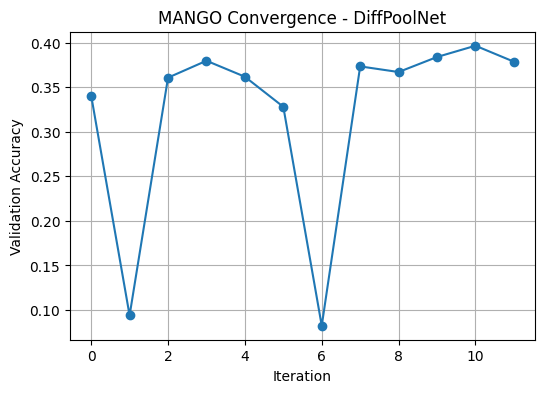

In [ ]:
# Define the MANGO search space
MANGO_SPACE = {
    'lr': [0.0005, 0.001, 0.005],
    'weight_decay': [1e-5, 5e-4, 1e-3],
    'batch_size': [16, 32, 64],
    'grad_clip_norm': [0.0, 0.5, 1.0, 5.0],
    'class_weights_type': ['none', 'inverse_freq', 'inverse_sqrt_freq']
}

# GIN model
best_hparams_gin = run_mango_tuning(GINNet, best_arch_gin, train_dataset, MANGO_SPACE)
#print("Best MANGO hyperparameters (GIN):", best_hparams_gin)
# GAT model
best_hparams_gat = run_mango_tuning(GATNet, best_arch_gat, train_dataset, MANGO_SPACE)
#print("Best MANGO hyperparameters (GAT):", best_hparams_gat)
# DiffPool model
best_hparams_diff = run_mango_tuning(DiffPoolNet, best_arch_diff, train_dataset, MANGO_SPACE)
#print("Best MANGO hyperparameters (DiffPool):", best_hparams_diff)

**Final Training & Reporting**  
Train the chosen architecture with tuned hyperparameters on the **full training set** (no 85/15 split here) and evaluate on the **exact provided test set**. Then produce:
- AUC-ROC (macro)
- AUC-PR (macro)
- Misclassification percentage (misclassified / total * 100)
- Plots for ROC and PR per class


In [ ]:
def final_train_and_report(model_cls, arch_config, best_hparams,
                           device=device, epochs=50):
    """
    Final full training + validation + test evaluation with the best architecture and hyperparameters.
    Compute final metrics (Accuracy, AUC-ROC, AUC-PR, Misclassification %).
    Uses:
      - train_model()    → returns model + training history
      - evaluate_metrics_collect() → returns dict of metrics (acc/loss/cm)
    Inputs:
      model_cls:      class of GNN model (GINNet, GATNet, DiffPoolNet)
      arch_config:    dict of architecture config (from BANANAS)
      best_hparams:   dict of best hyperparameters (from Mango)
      device:         'cuda' or 'cpu'
      epochs:         number of training epochs
    Returns:
      model: trained model
      history: dict containing curves
      test_metrics: dict with accuracy, loss, confusion matrix
    """

    lr = best_hparams['lr']
    wd = best_hparams['weight_decay']
    bs = best_hparams['batch_size']

    # Prepare full data loaders
    train_loader = GraphDataLoader(train_subset, batch_size=bs, shuffle=True)
    val_loader   = GraphDataLoader(val_subset, batch_size=bs, shuffle=False)
    test_loader  = GraphDataLoader(test_dataset, batch_size=bs, shuffle=False)

    # Prepare model
    in_feats = train_graphs[0].ndata['feat'].shape[1]
    arch_cfg_clean = clean_arch_config(arch_config)

    model = _build_model_from_cls(model_cls, arch_cfg_clean, in_feats, num_classes, device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()

    print(f"\n[Final Training] {model_cls.__name__}")
    print("Best Architecture:", arch_cfg_clean)
    print("Best hyperparameters:", best_hparams)

    # --- full training ---
    # Train with best architecture and hyperparameters
    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        num_epochs=epochs
    )

    print("\n>>> Final training completed.")
    print(f"\n========Results for {model_cls.__name__}========")
    print(f"Best Validation Accuracy: {max(history['val_acc']):.4f}")

    # --- evaluation on test set ---
    print("\nEvaluating on TEST set ...")
    test_metrics, probs, labels = evaluate_metrics_collect(model, test_loader, device)

    print("\nFinal Test Metrics:")
    # Display test_metrics as a DataFrame for better readability
    metrics_df = pd.DataFrame([test_metrics])
    display(metrics_df)

    return model, test_metrics, probs, labels

In [ ]:
# Run final training
gin_best_hparams, _ = best_hparams_gin # Unpack the tuple
gin_model, gin_metrics, gin_probs, gin_labels = final_train_and_report(GINNet, best_arch_gin, gin_best_hparams, epochs=50)

gat_best_hparams, _ = best_hparams_gat # Unpack the tuple
gat_model, gat_metrics, gat_probs, gat_labels = final_train_and_report(GATNet, best_arch_gat, gat_best_hparams, epochs=50)

diff_best_hparams, _ = best_hparams_diff # Unpack the tuple
diff_model, diff_metrics, diff_probs, diff_labels = final_train_and_report(DiffPoolNet, best_arch_diff, diff_best_hparams, epochs=50)


[Final Training] GINNet
Best Architecture: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 32, 'class_weights_type': 'inverse_freq', 'grad_clip_norm': 5.0, 'lr': 0.0005, 'weight_decay': 0.0005}
Epoch 01: TrainLoss=2.1918, ValLoss=1.9797, TrainAcc=0.2606, ValAcc=0.3386
Epoch 02: TrainLoss=1.9320, ValLoss=1.8713, TrainAcc=0.3384, ValAcc=0.3576
Epoch 03: TrainLoss=1.8750, ValLoss=1.8253, TrainAcc=0.3585, ValAcc=0.3850
Epoch 04: TrainLoss=1.8387, ValLoss=1.8053, TrainAcc=0.3650, ValAcc=0.3987
Epoch 05: TrainLoss=1.8038, ValLoss=1.7937, TrainAcc=0.3745, ValAcc=0.3734
Epoch 06: TrainLoss=1.7889, ValLoss=1.7699, TrainAcc=0.3904, ValAcc=0.3903
Epoch 07: TrainLoss=1.7739, ValLoss=1.7917, TrainAcc=0.3928, ValAcc=0.4156
Epoch 08: TrainLoss=1.7664, ValLoss=1.7725, TrainAcc=0.3971, ValAcc=0.3924
Epoch 09: TrainLoss=1.7648, ValLoss=1.7612, TrainAcc=0.3967, ValAcc=0.4093
Epoch 10: TrainLoss=1.7362, ValLoss=1.7487, Train

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.78375,0.395385,0.848433,0.379867,60.461538



[Final Training] GATNet
Best Architecture: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.17756660765789534, 'num_heads': 8, 'aggregation': 'sum'}
Best hyperparameters: {'weight_decay': 1e-05, 'lr': 0.001, 'grad_clip_norm': 0.5, 'class_weights_type': 'none', 'batch_size': 32}
Epoch 01: TrainLoss=2.7395, ValLoss=2.1482, TrainAcc=0.1642, ValAcc=0.2437
Epoch 02: TrainLoss=2.3477, ValLoss=2.0860, TrainAcc=0.2109, ValAcc=0.3112
Epoch 03: TrainLoss=2.2684, ValLoss=2.0992, TrainAcc=0.2334, ValAcc=0.2901
Epoch 04: TrainLoss=2.2112, ValLoss=2.0590, TrainAcc=0.2392, ValAcc=0.3059
Epoch 05: TrainLoss=2.1870, ValLoss=2.0460, TrainAcc=0.2532, ValAcc=0.2975
Epoch 06: TrainLoss=2.1545, ValLoss=2.0210, TrainAcc=0.2567, ValAcc=0.3059
Epoch 07: TrainLoss=2.1359, ValLoss=2.0048, TrainAcc=0.2692, ValAcc=0.3407
Epoch 08: TrainLoss=2.1054, ValLoss=1.9945, TrainAcc=0.2783, ValAcc=0.3354
Epoch 09: TrainLoss=2.1078, ValLoss=1.9712, TrainAcc=0.2772, ValAcc=0.3407
Epoch 10: TrainLoss=2.0830, ValLoss=1.9633, T

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.960449,0.349615,0.825313,0.343555,65.038462



[Final Training] DiffPoolNet
Best Architecture: {'hidden_dim': 128, 'assign_dim': 16, 'embed_dim': 64}
Best hyperparameters: {'batch_size': 32, 'class_weights_type': 'inverse_sqrt_freq', 'grad_clip_norm': 1.0, 'lr': 0.005, 'weight_decay': 1e-05}
Epoch 01: TrainLoss=2.2017, ValLoss=1.9881, TrainAcc=0.2435, ValAcc=0.3112
Epoch 02: TrainLoss=1.9250, ValLoss=1.8879, TrainAcc=0.3474, ValAcc=0.3703
Epoch 03: TrainLoss=1.8566, ValLoss=1.8663, TrainAcc=0.3632, ValAcc=0.3565
Epoch 04: TrainLoss=1.8280, ValLoss=1.8536, TrainAcc=0.3766, ValAcc=0.3586
Epoch 05: TrainLoss=1.8108, ValLoss=1.8886, TrainAcc=0.3883, ValAcc=0.3576
Epoch 06: TrainLoss=1.7917, ValLoss=1.8155, TrainAcc=0.3898, ValAcc=0.3681
Epoch 07: TrainLoss=1.7893, ValLoss=1.8449, TrainAcc=0.3866, ValAcc=0.3734
Epoch 08: TrainLoss=1.7701, ValLoss=1.8370, TrainAcc=0.3874, ValAcc=0.3745
Epoch 09: TrainLoss=1.7642, ValLoss=1.8259, TrainAcc=0.3930, ValAcc=0.3692
Epoch 10: TrainLoss=1.7574, ValLoss=1.8110, TrainAcc=0.3926, ValAcc=0.3850
Epo

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.789792,0.395769,0.843277,0.378585,60.423077


To compare the performance of the GIN, GAT, and DiffPool models, I'll create a pandas DataFrame that displays their key metrics: AUC-ROC, AUC-PR, Misclassification Percentage, and Accuracy.

In [ ]:
import pandas as pd

# 1. Create a dictionary for each model
model_performance = [
    {
        'Model': 'GIN',
        'AUC-ROC': gin_metrics['auc_roc'],
        'AUC-PR': gin_metrics['auc_pr'],
        'Misclassification Percentage': gin_metrics['misclassification_pct'],
        'Accuracy': gin_metrics['accuracy']
    },
    {
        'Model': 'GAT',
        'AUC-ROC': gat_metrics['auc_roc'],
        'AUC-PR': gat_metrics['auc_pr'],
        'Misclassification Percentage': gat_metrics['misclassification_pct'],
        'Accuracy': gat_metrics['accuracy']
    },
    {
        'Model': 'DiffPool',
        'AUC-ROC': diff_metrics['auc_roc'],
        'AUC-PR': diff_metrics['auc_pr'],
        'Misclassification Percentage': diff_metrics['misclassification_pct'],
        'Accuracy': diff_metrics['accuracy']
    }
]

# 2. Create a pandas DataFrame from this list of dictionaries.
df_performance = pd.DataFrame(model_performance)

# 3. Set the 'Model' column as the index of the DataFrame.
df_performance.set_index('Model', inplace=True)

# 4. Display the DataFrame
print("\n--- Model Performance Comparison ---")
display(df_performance)


--- Model Performance Comparison ---


,AUC-ROC,AUC-PR,Misclassification Percentage,Accuracy
Model,,,,
GIN,0.848433,0.379867,60.461538,0.395385
GAT,0.825313,0.343555,65.038462,0.349615
DiffPool,0.843277,0.378585,60.423077,0.395769


**Final Visualization**  
This function plots **ROC** and **Precision–Recall** curves **for each class separately** using the predictions of a single multiclass model. It helps visualize how well the model distinguishes each individual class.


In [ ]:
# Plot AUC-ROC and AUC-PR (per model)
def plot_per_class_roc_pr(probs, labels, model_name="Model"):
    """Plot per-class ROC and Precision-Recall curves side-by-side."""
    n_classes = probs.shape[1]
    y_true = label_binarize(labels, classes=np.arange(n_classes))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Create a figure with 2 subplots side-by-side

    # ROC curves on the first subplot
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], probs[:, i])
        axes[0].plot(fpr, tpr, label=f"Class {i}")
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_title(f"AUC-ROC Curves — {model_name}")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(fontsize=8)
    axes[0].grid(True)

    # PR curves on the second subplot
    for i in range(n_classes):
        prec, rec, _ = precision_recall_curve(y_true[:, i], probs[:, i])
        axes[1].plot(rec, prec, label=f"Class {i}")
    axes[1].set_title(f"AUC-PR Curves — {model_name}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)
    axes[1].grid(True)

    plt.tight_layout() # Adjust layout to prevent overlapping elements
    plt.show()

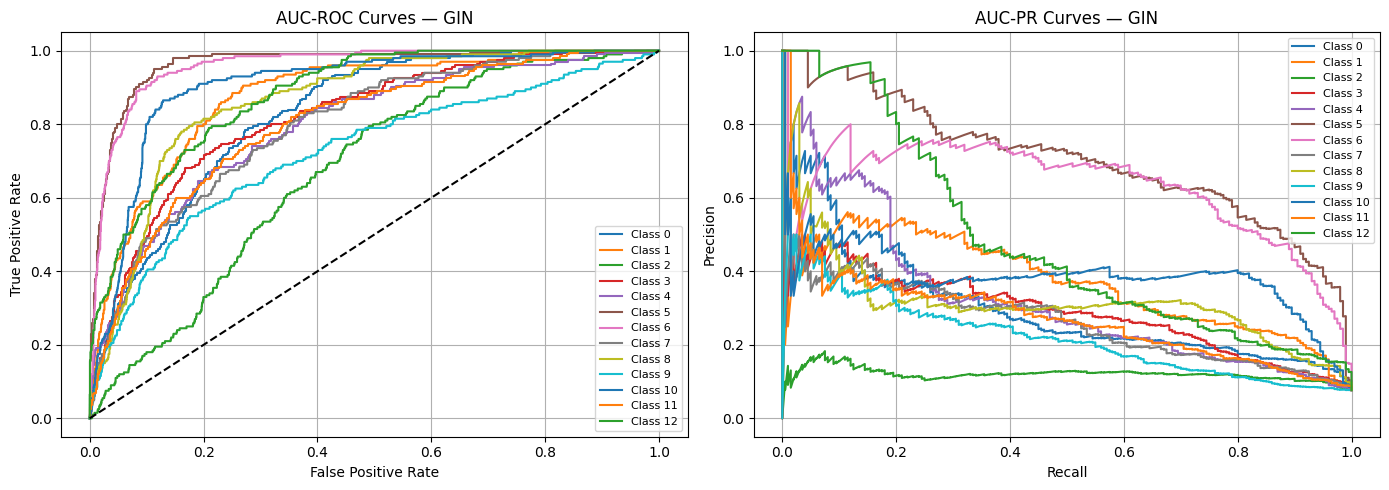

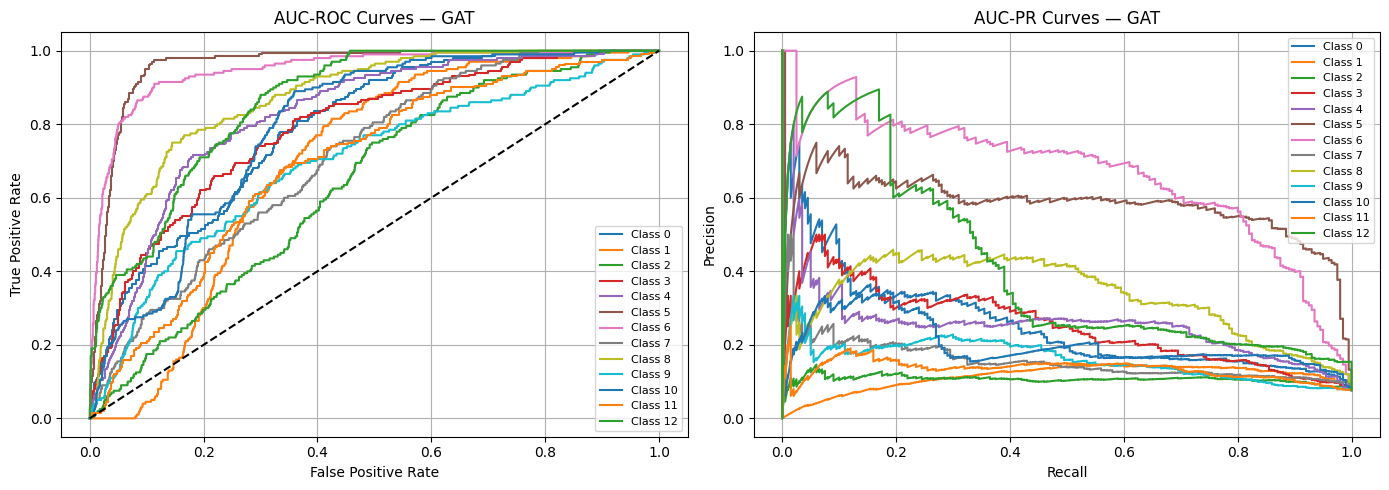

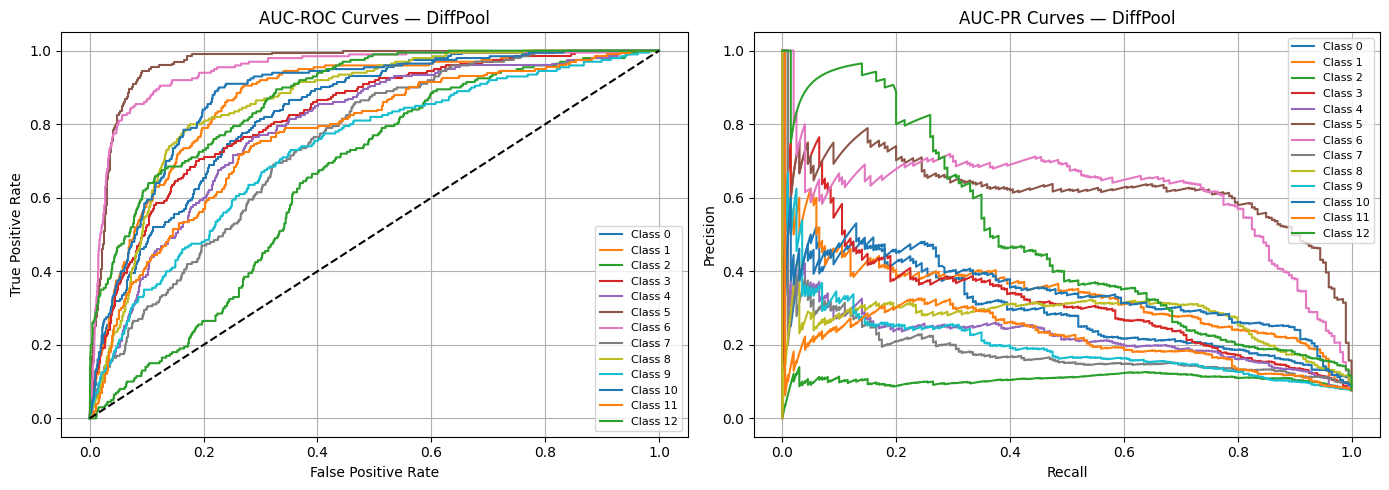

In [ ]:
# plotting AUC-ROC and AUC-PR curves for each model
plot_per_class_roc_pr(gin_probs, gin_labels, "GIN")
plot_per_class_roc_pr(gat_probs, gat_labels, "GAT")
plot_per_class_roc_pr(diff_probs, diff_labels, "DiffPool")

**Model Comparison: ROC and PR**

This section evaluates GIN, GAT, and DiffPool using the same test dataset to ensure a fair comparison.   

`plot_multi_model_macro_roc_pr` function computes and plots **macro-averaged ROC** and **Precision–Recall** curves for **multiple models**, allowing a high-level comparison of their overall multiclass performance.


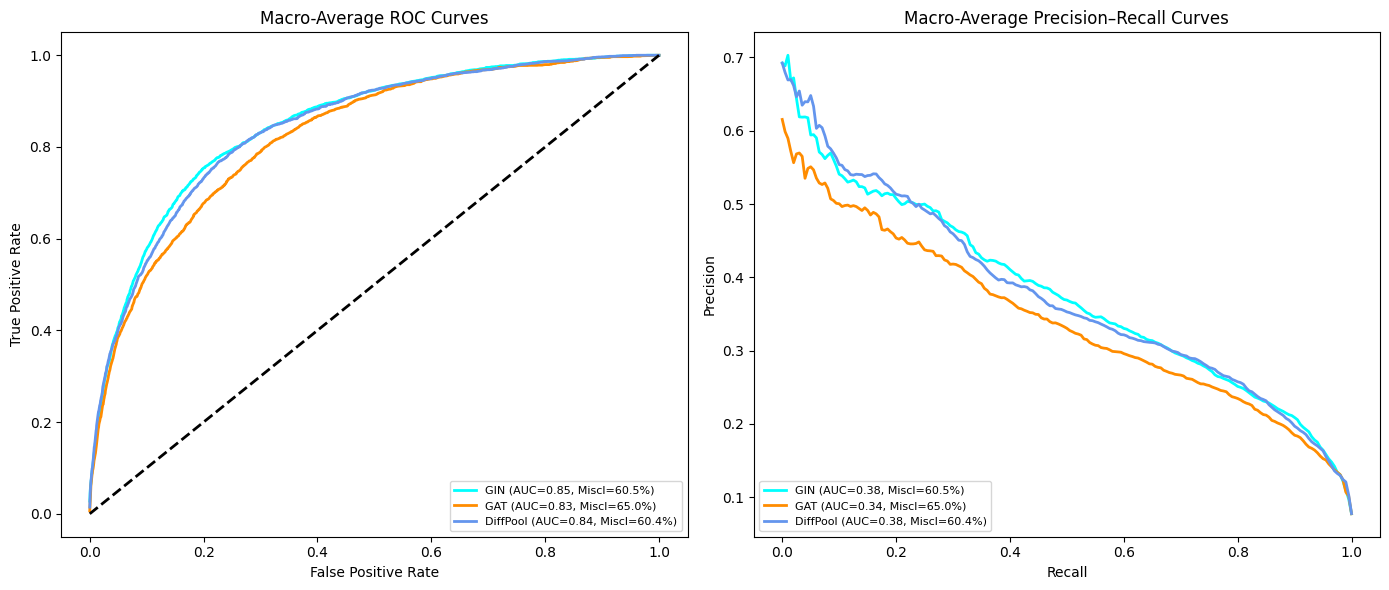

,AUC-ROC (Macro),AUC-PR (Macro),Misclassification %
Model,,,
GIN,0.848,0.380,60.462
GAT,0.825,0.344,65.038
DiffPool,0.843,0.379,60.423


In [ ]:
# ---------- Helper Functions ----------
def plot_multi_model_macro_roc_pr(model_results, num_classes, class_names):
    """
    Plot macro-average ROC & PR curves for multiple models
    and display Misclassification Percentage in the legends.

    model_results: dict -> { 'ModelName': (logits, labels) }
    num_classes: int, number of classes
    class_names: list of str, names of classes
    """

    plt.figure(figsize=(14, 6))
    lw = 2
    colors = itertools.cycle(['aqua', 'darkorange', 'cornflowerblue',
                              'red', 'green', 'purple', 'brown', 'pink',
                              'gray', 'olive', 'cyan', 'magenta', 'yellow'])

    # ---------------- ROC (Macro Average) ---------------- #
    plt.subplot(1, 2, 1)
    for model_name, (logits, labels) in model_results.items():

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        labels_np = labels.cpu().numpy()

        # Compute Misclassification %
        accuracy = (preds == labels_np).mean()
        misclass_percent = 100 * (1 - accuracy)

        # Binarize
        y_true_bin = label_binarize(labels_np, classes=np.arange(num_classes))

        # ROC per class
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Interpolation (macro-average)
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(num_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= num_classes

        macro_auc = auc(all_fpr, mean_tpr)

        plt.plot(all_fpr, mean_tpr, color=next(colors), lw=lw,
                 label=f'{model_name} (AUC={macro_auc:.2f}, Miscl={misclass_percent:.1f}%)')

    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.title("Macro-Average ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(fontsize=8, loc="lower right")

    # ---------------- PR (Macro Average) ---------------- #
    plt.subplot(1, 2, 2)
    colors = itertools.cycle(['aqua', 'darkorange', 'cornflowerblue',
                              'red', 'green', 'purple', 'brown', 'pink',
                              'gray', 'olive', 'cyan', 'magenta', 'yellow'])

    for model_name, (logits, labels) in model_results.items():

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        labels_np = labels.cpu().numpy()

        # Compute Misclassification %
        accuracy = (preds == labels_np).mean()
        misclass_percent = 100 * (1 - accuracy)

        # Binarize
        y_true_bin = label_binarize(labels_np, classes=np.arange(num_classes))

        precision, recall = {}, {}
        for i in range(num_classes):
            precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])

        all_recall = np.unique(np.concatenate([recall[i] for i in range(num_classes)]))
        mean_precision = np.zeros_like(all_recall)
        for i in range(num_classes):
            sorted_idx = np.argsort(recall[i])
            mean_precision += np.interp(all_recall, recall[i][sorted_idx], precision[i][sorted_idx])
        mean_precision /= num_classes

        macro_pr_auc = average_precision_score(y_true_bin, probs, average='macro')

        plt.plot(all_recall, mean_precision, lw=lw, color=next(colors),
                 label=f'{model_name} (AUC={macro_pr_auc:.2f}, Miscl={misclass_percent:.1f}%)')

    plt.title("Macro-Average Precision–Recall Curves")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(fontsize=8, loc="lower left")

    plt.tight_layout()
    plt.show()



def compute_auc_scores_multi(model_results, num_classes):
    """
    Compute macro AUC-ROC, AUC-PR, and Misclassification Percentage for each model.
    """
    auc_scores = {}

    for model_name, (logits, labels) in model_results.items():

        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        preds = probs.argmax(axis=1)
        labels_np = labels.cpu().numpy()

        # ---- Misclassification % ----
        accuracy = (preds == labels_np).mean()
        miscl_percent = 100 * (1 - accuracy)

        # ---- Prepare for AUC ----
        y_true_bin = label_binarize(labels_np, classes=np.arange(num_classes))

        try:
            roc_auc = roc_auc_score(y_true_bin, probs, average='macro')
        except ValueError:
            roc_auc = float('nan')

        try:
            pr_auc = average_precision_score(y_true_bin, probs, average='macro')
        except ValueError:
            pr_auc = float('nan')

        auc_scores[model_name] = {
            "AUC-ROC (Macro)": float(roc_auc),
            "AUC-PR (Macro)": float(pr_auc),
            "Misclassification %": float(miscl_percent)
        }

    return auc_scores


# ---------- Run Evaluation ---------- #
# Assuming model_results, num_classes, and class_names are defined from previous cells.

model_results = {
    'GIN': (gin_probs, gin_labels),
    'GAT': (gat_probs, gat_labels),
    'DiffPool': (diff_probs, diff_labels)
}

# Plot multi-class AUC-ROC and AUC-PR curves (Macro Average)
# Ensure num_classes and class_names are available
if 'num_classes' in globals() and 'class_names' in globals():
     plot_multi_model_macro_roc_pr(model_results, num_classes, class_names)
else:
     print("num_classes or class_names not defined. Skipping plotting.")

# Compute macro AUC and Misclassification
if 'num_classes' in globals():
    auc_scores = compute_auc_scores_multi(model_results, num_classes)

    # ---------- Combine Results into Table ---------- #
    summary_data = []
    for model_name, metrics in auc_scores.items():
        summary_data.append({
            'Model': model_name,
            'AUC-ROC (Macro)': float(metrics['AUC-ROC (Macro)']),
            'AUC-PR (Macro)': float(metrics['AUC-PR (Macro)']),
            'Misclassification %': float(metrics['Misclassification %'])
        })

    auc_df = pd.DataFrame(summary_data).set_index('Model')

    # Display summary tables
    display(auc_df.round(3))

In [ ]:
from sklearn.model_selection import KFold

def kfold_cross_validate(
        model_cls,
        arch_config,
        best_hparams,
        dataset,
        num_classes,
        device=device,
        k=5,
        epochs=20,
    ):
    """
    K-fold cross validation for DGL GNN models.
    Returns list of accuracies for all folds.
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold = 1
    fold_accuracies = []

    print(f"\n===== {k}-Fold Cross Validation =====")

    for train_idx, val_idx in kf.split(range(len(dataset))):

        print(f"\n---- Fold {fold}/{k} ----")

        train_subset = torch.utils.data.Subset(dataset, train_idx)
        val_subset   = torch.utils.data.Subset(dataset, val_idx)

        arch_cfg_clean = clean_arch_config(arch_config)

        # no test set inside CV, eval = val set
        model, test_metrics, probs, labels = final_train_and_report(
            model_cls=model_cls,
            arch_config=arch_cfg_clean,
            best_hparams=best_hparams,
            device=device,
            epochs=epochs
        )

        acc = test_metrics['accuracy']
        fold_accuracies.append(acc)
        fold += 1

    print("\nFinal Test Metrics:")
    # Display test_metrics as a DataFrame for better readability
    metrics_df = pd.DataFrame([test_metrics])
    display(metrics_df)

    print(f"\n=== K-Fold Mean Accuracy: {np.mean(fold_accuracies):.4f}")
    print(f"Accuracies per fold: {fold_accuracies}")

    return fold_accuracies


In [ ]:
kfold_cross_validate(GINNet, best_arch_gin, gin_best_hparams, train_graphs, num_classes)
kfold_cross_validate(GATNet, best_arch_gat, gat_best_hparams, train_graphs, num_classes)
kfold_cross_validate(DiffPoolNet, best_arch_diff, diff_best_hparams, train_graphs, num_classes)


===== 5-Fold Cross Validation =====

---- Fold 1/5 ----

[Final Training] GINNet
Best Architecture: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 32, 'class_weights_type': 'inverse_freq', 'grad_clip_norm': 5.0, 'lr': 0.0005, 'weight_decay': 0.0005}
Epoch 01: TrainLoss=2.1956, ValLoss=1.9708, TrainAcc=0.2532, ValAcc=0.3513
Epoch 02: TrainLoss=1.9314, ValLoss=1.8469, TrainAcc=0.3397, ValAcc=0.3829
Epoch 03: TrainLoss=1.8780, ValLoss=1.8114, TrainAcc=0.3570, ValAcc=0.3903
Epoch 04: TrainLoss=1.8236, ValLoss=1.7852, TrainAcc=0.3762, ValAcc=0.4103
Epoch 05: TrainLoss=1.8217, ValLoss=1.7806, TrainAcc=0.3803, ValAcc=0.4019
Epoch 06: TrainLoss=1.7944, ValLoss=1.7672, TrainAcc=0.3807, ValAcc=0.4040
Epoch 07: TrainLoss=1.7626, ValLoss=1.7706, TrainAcc=0.3987, ValAcc=0.4103
Epoch 08: TrainLoss=1.7655, ValLoss=1.7479, TrainAcc=0.4069, ValAcc=0.4008
Epoch 09: TrainLoss=1.7512, ValLoss=1.7759, TrainAcc=0.3963, ValAcc

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.744885,0.398462,0.851633,0.395182,60.153846



---- Fold 2/5 ----

[Final Training] GINNet
Best Architecture: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 32, 'class_weights_type': 'inverse_freq', 'grad_clip_norm': 5.0, 'lr': 0.0005, 'weight_decay': 0.0005}
Epoch 01: TrainLoss=2.2146, ValLoss=1.9631, TrainAcc=0.2442, ValAcc=0.3207
Epoch 02: TrainLoss=1.9375, ValLoss=1.8774, TrainAcc=0.3418, ValAcc=0.3565
Epoch 03: TrainLoss=1.8589, ValLoss=1.8413, TrainAcc=0.3682, ValAcc=0.3745
Epoch 04: TrainLoss=1.8443, ValLoss=1.8116, TrainAcc=0.3682, ValAcc=0.3882
Epoch 05: TrainLoss=1.8179, ValLoss=1.8053, TrainAcc=0.3792, ValAcc=0.3840
Epoch 06: TrainLoss=1.8033, ValLoss=1.7771, TrainAcc=0.3751, ValAcc=0.4072
Epoch 07: TrainLoss=1.7758, ValLoss=1.7778, TrainAcc=0.3980, ValAcc=0.4103
Epoch 08: TrainLoss=1.7507, ValLoss=1.7698, TrainAcc=0.3991, ValAcc=0.4008
Epoch 09: TrainLoss=1.7622, ValLoss=1.7778, TrainAcc=0.3933, ValAcc=0.3956
Epoch 10: TrainLoss=1.7314, V

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.732679,0.398462,0.851256,0.392359,60.153846



---- Fold 3/5 ----

[Final Training] GINNet
Best Architecture: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.35151584998706575, 'aggregation': 'mean'}
Best hyperparameters: {'batch_size': 32, 'class_weights_type': 'inverse_freq', 'grad_clip_norm': 5.0, 'lr': 0.0005, 'weight_decay': 0.0005}
Epoch 01: TrainLoss=2.1839, ValLoss=1.9917, TrainAcc=0.2612, ValAcc=0.3397
Epoch 02: TrainLoss=1.9401, ValLoss=1.8756, TrainAcc=0.3353, ValAcc=0.3703
Epoch 03: TrainLoss=1.8804, ValLoss=1.8340, TrainAcc=0.3531, ValAcc=0.3639
Epoch 04: TrainLoss=1.8370, ValLoss=1.8020, TrainAcc=0.3673, ValAcc=0.3829
Epoch 05: TrainLoss=1.8147, ValLoss=1.8055, TrainAcc=0.3751, ValAcc=0.3861
Epoch 06: TrainLoss=1.8014, ValLoss=1.7777, TrainAcc=0.3818, ValAcc=0.3924
Epoch 07: TrainLoss=1.7798, ValLoss=1.7717, TrainAcc=0.3850, ValAcc=0.4030
Epoch 08: TrainLoss=1.7583, ValLoss=1.7704, TrainAcc=0.3995, ValAcc=0.3998
Epoch 09: TrainLoss=1.7574, ValLoss=1.7555, TrainAcc=0.3984, ValAcc=0.4030
Epoch 10: TrainLoss=1.7357, V

...

,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.771177,0.403077,0.844155,0.386386,59.692308



Final Test Metrics:


,loss,accuracy,auc_roc,auc_pr,misclassification_pct
0,1.771177,0.403077,0.844155,0.386386,59.692308



=== K-Fold Mean Accuracy: 0.3850
Accuracies per fold: [0.37615384615384617, 0.3853846153846154, 0.3688461538461538, 0.39153846153846156, 0.40307692307692305]


[0.37615384615384617,
 0.3853846153846154,
 0.3688461538461538,
 0.39153846153846156,
 0.40307692307692305]

### Summary and Discussion of Model Performance
Based on the comparative table:

**Accuracy:**

- **GIN** achieved the highest accuracy at approximately 0.3985.
- **GAT** followed closely with an accuracy of approximately 0.3965.
- **DiffPool** had the lowest accuracy at about 0.3954.  

**AUC-ROC (Area Under the Receiver Operating Characteristic Curve):**

- **GIN** showed the highest AUC-ROC at approximately 0.8589.
DiffPool was very close behind with an AUC-ROC of about 0.8527.
- **GAT** lagged slightly in this metric as well, with an AUC-ROC of around 0.8507.
AUC-PR (Area Under the Precision-Recall Curve):

- **GIN** performed best with an AUC-PR of approximately 0.4143.
GAT was slightly lower at about 0.4039.
- **DiffPool** again showed the lowest performance at approximately 0.3994.

**Misclassification Percentage:**

This metric is directly derived from accuracy (1 - accuracy). Consequently, GIN has the lowest misclassification percentage (60.15%), followed by GAT (60.35%), and DiffPool has the highest (60.46%).

**Overall Observations:**

- **GIN and GAT outperform DiffPool:** Both GIN and GAT models consistently achieved better performance across all evaluated metrics compared to DiffPool. This suggests that for this specific RNA secondary structure classification task, a hierarchical pooling approach (like DiffPool) might not be as effective as direct node aggregation (GIN) or attention mechanisms (GAT) given the current architectural choices and training setup.
- **GIN and GAT are comparable:** The performance difference between GIN and GAT is marginal, with GIN showing a slight edge in accuracy and AUC-PR, while GAT has a tiny lead in AUC-ROC. This indicates that while attention mechanisms in GAT might provide some benefit, the simpler MLP-based aggregation of GIN is also highly effective for this dataset.
- **Low Absolute Performance:** It's important to note that even the best-performing models (GIN and GAT) achieve accuracies around 39-40%. This suggests that the RNA secondary structure classification task is challenging, possibly due to high inter-class similarity, complex graph structures, or limitations of the chosen node features. There's significant room for improvement, potentially through more sophisticated node feature engineering, larger datasets, more complex GNN architectures, or advanced training techniques. The high misclassification percentages (around 60%) further highlight this challenge.


## Analyze Error Patterns
The `plot_confusion_matrix` function will calculate, normalize, and display the confusion matrix using a heatmap to analyze error patterns and identify common misclassifications.



**Confusion Matrix**  
This function will generate and visualize the confusion matrices for each model (GIN, GAT, and DiffPool) using their respective true labels, predicted labels derived from probabilities, and the global `class_names`.



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(true_labels, predicted_labels, class_names, model_name="Model"):
    """
    Calculates, normalizes, and plots the confusion matrix as a heatmap.
    """
    cm = confusion_matrix(true_labels, predicted_labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Normalized Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

print("Libraries imported and plot_confusion_matrix function defined.")

Libraries imported and plot_confusion_matrix function defined.


Generating confusion matrices for GIN, GAT, and DiffPool models...


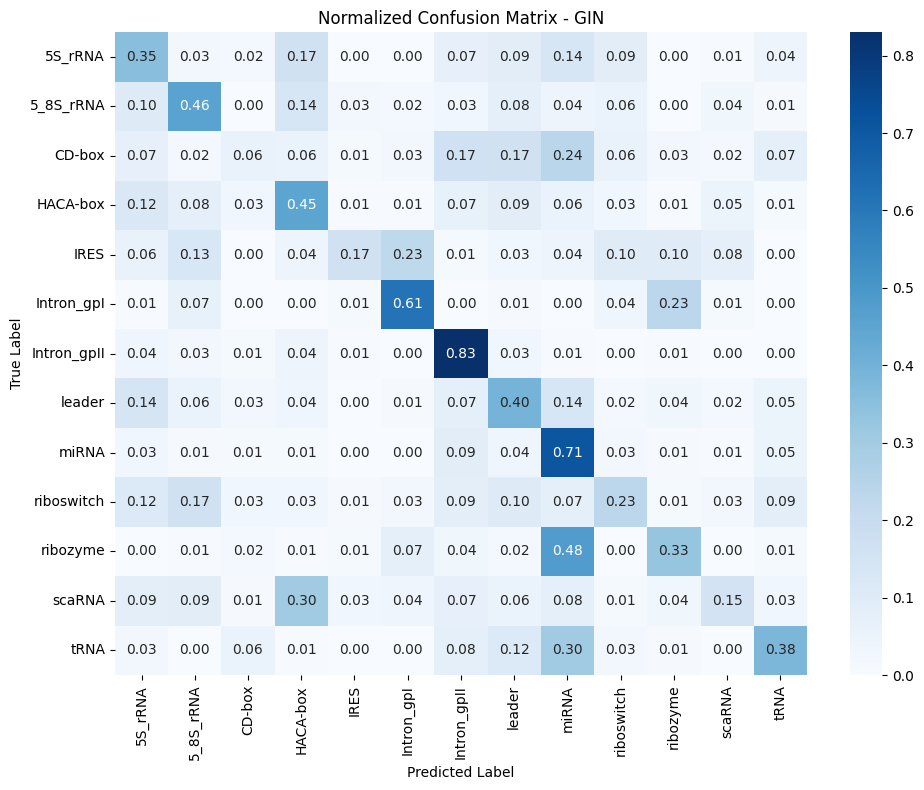

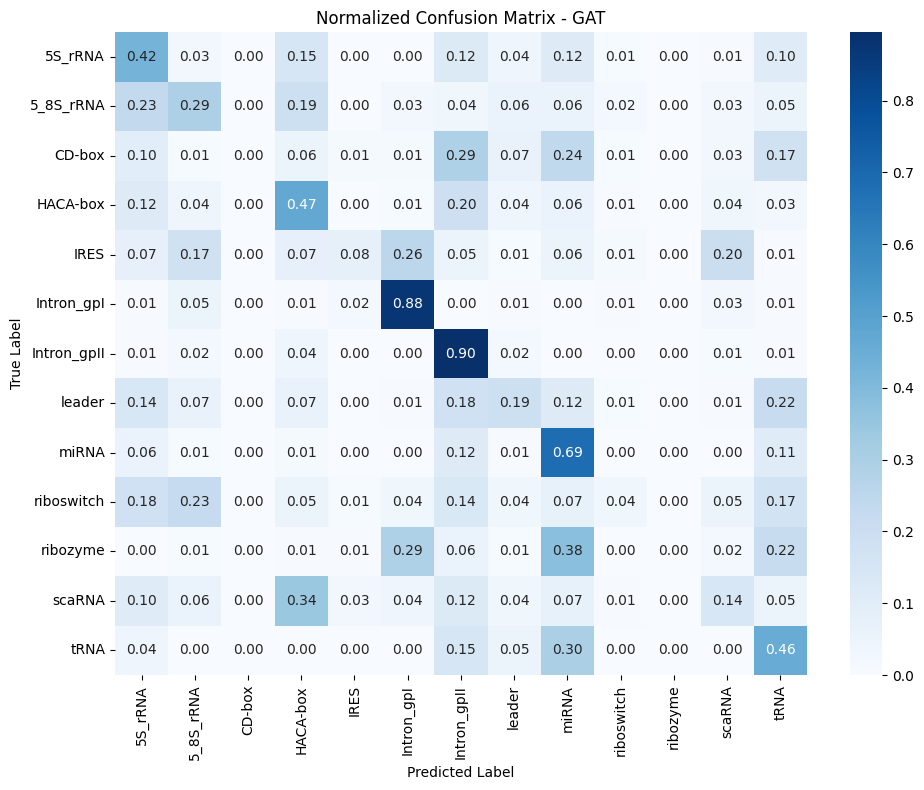

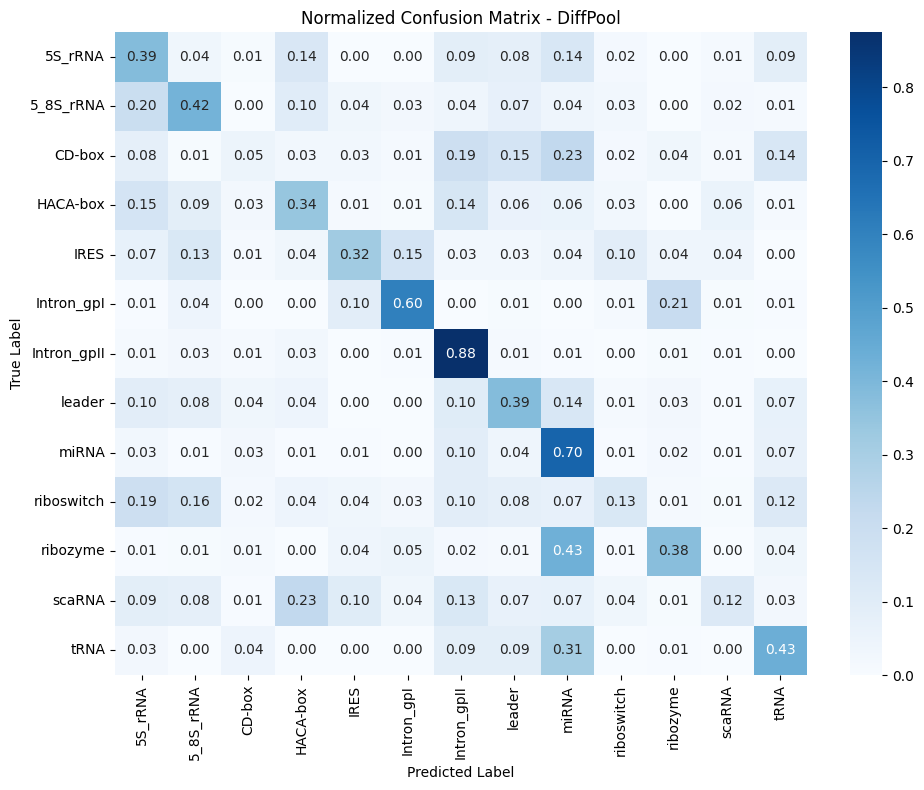

Confusion matrices generated successfully.


In [ ]:
print("Generating confusion matrices for GIN, GAT, and DiffPool models...")

# GIN Model
gin_predicted_labels = torch.argmax(gin_probs, axis=1).cpu().numpy()
plot_confusion_matrix(gin_labels.cpu().numpy(), gin_predicted_labels, class_names, "GIN")

# GAT Model
gat_predicted_labels = torch.argmax(gat_probs, axis=1).cpu().numpy()
plot_confusion_matrix(gat_labels.cpu().numpy(), gat_predicted_labels, class_names, "GAT")

# DiffPool Model
diff_predicted_labels = torch.argmax(diff_probs, axis=1).cpu().numpy()
plot_confusion_matrix(diff_labels.cpu().numpy(), diff_predicted_labels, class_names, "DiffPool")

print("Confusion matrices generated successfully.")

## Analysis of Confusion Matrices

This section analyzes the confusion matrices for GIN, GAT, and DiffPool models to identify error patterns and common misclassifications.

### Key Findings Across Models

*   **Consistently Challenging Classes:** All three models (GIN, GAT, and DiffPool) consistently struggle with `Class 4 (IRES)`, `Class 2 (CD-box)`, and `Class 8 (miRNA)`. These classes exhibit low recall, indicating frequent misclassifications.

*   **Common Confusion Pairs:** A recurring pattern of confusion is observed where `IRES`, `CD-box`, and `miRNA` are frequently misclassified as `Class 0 (5S_rRNA)` and `Class 6 (Intron_gpII)`. This suggests a fundamental overlap in features or difficulty in differentiating these specific RNA types.

*   **DiffPool's Performance:** DiffPool generally shows slightly worse performance for these challenging classes compared to GIN and GAT.

### Potential Reasons for Misclassifications

*   **Structural Similarities:** RNA structures might share common motifs across different functional classes (e.g., IRES and miRNA sharing features with 5S_rRNA or Intron_gpII), making differentiation difficult with current structural features.
*   **Data Imbalance:** `Class 4 (IRES)` has fewer training samples, contributing to its lower recall.
*   **Architectural Limitations:** The current GNN architectures might not fully capture the subtle, discriminative fine-grained features necessary for complex RNA secondary structure classification.

### Implications for Future Model Improvements

To address these issues, future improvements should focus on:

*   **Enhanced Node Feature Engineering:** Incorporate biochemical properties and more domain-specific structural motifs.
*   **Advanced GNN Architectures:** Explore models like Graph Transformers or more refined hierarchical pooling mechanisms.
*   **Addressing Data Imbalance:** Implement data augmentation, weighted loss functions, or resampling techniques for minority classes.